## 01. Notebook에서 DB 분석 시작


In [1]:

from pathlib import Path
import sys

import pandas as pd
from sqlalchemy import text
from IPython.display import display

# 1. ai/ 프로젝트 루트 자동 탐색
current = Path.cwd().resolve()

AI_ROOT = next(
    (
        path for path in [current, *current.parents]
        if (path / "src/core/database.py").exists()
    ),
    None,
)

if AI_ROOT is None:
    raise RuntimeError("ai/ 프로젝트 루트를 찾지 못했습니다.")

if str(AI_ROOT) not in sys.path:
    sys.path.insert(0, str(AI_ROOT))

# 2. 기존 PostgreSQL 연결 재사용
from src.core.database import get_engine

engine = get_engine()

# 3. DB 연결 확인
with engine.connect() as conn:
    db_name = conn.execute(
        text("SELECT current_database()")
    ).scalar_one()

print("연결된 DB:", db_name)

# 4. 실제 존재하는 데이터 테이블 탐색
query = text("""
    SELECT
        table_schema,
        table_name
    FROM information_schema.tables
    WHERE table_schema NOT IN (
        'pg_catalog',
        'information_schema'
    )
    AND table_type = 'BASE TABLE'
    ORDER BY table_schema, table_name
""")

with engine.connect() as conn:
    tables = pd.read_sql(query, conn)

# 위험 분석에 연관될 수 있는 테이블 후보
keywords = (
    "accident",
    "risk",
    "care",
    "job",
    "stat",
    "public_record",
)

candidates = tables[
    tables["table_name"].str.lower().apply(
        lambda name: any(
            keyword in name for keyword in keywords
        )
    )
].copy()

print("전체 테이블:", len(tables))
print("F-002 관련 후보:", len(candidates))

display(candidates)


연결된 DB: if_spring
전체 테이블: 46
F-002 관련 후보: 13


,table_schema,table_name
5,analytics,dim_job
7,analytics,dim_risk_grade
10,external_ref,accident_age_stat
11,external_ref,accident_industry_stat
12,external_ref,accident_labor_office_stat
13,external_ref,accident_size_stat
14,external_ref,ai_job_risk_profile
18,external_ref,job_posting_reference
19,external_ref,job_reference
21,external_ref,ltc_recognition_stat


## Notebook Cell 02 — 테이블 구조 분석

In [2]:
from sqlalchemy import inspect, text
from IPython.display import display
import pandas as pd

inspector = inspect(engine)

table_results = []
column_results = []

for row in candidates.itertuples(index=False):
    schema = row.table_schema
    table = row.table_name

    # SQL 식별자를 안전하게 인용
    full_name = (
        f"{engine.dialect.identifier_preparer.quote(schema)}."
        f"{engine.dialect.identifier_preparer.quote(table)}"
    )

    # 테이블별 데이터 건수
    try:
        with engine.connect() as conn:
            count = conn.execute(
                text(f"SELECT COUNT(*) FROM {full_name}")
            ).scalar_one()

        status = "OK"
    except Exception as exc:
        count = None
        status = f"ERROR: {str(exc)[:120]}"

    table_results.append({
        "schema": schema,
        "table": table,
        "rows": count,
        "status": status,
    })

    # 컬럼 구조
    for col in inspector.get_columns(table, schema=schema):
        column_results.append({
            "schema": schema,
            "table": table,
            "column": col["name"],
            "type": str(col["type"]),
            "nullable": col["nullable"],
        })

table_summary = pd.DataFrame(table_results)
column_summary = pd.DataFrame(column_results)

print("=== 테이블별 건수 ===")
display(table_summary)

print("=== 테이블별 컬럼 ===")
display(column_summary)

=== 테이블별 건수 ===


,schema,table,rows,status
0,analytics,dim_job,5,OK
1,analytics,dim_risk_grade,3,OK
2,external_ref,accident_age_stat,1599,OK
3,external_ref,accident_industry_stat,2880,OK
4,external_ref,accident_labor_office_stat,5733,OK
5,external_ref,accident_size_stat,1800,OK
6,external_ref,ai_job_risk_profile,0,OK
7,external_ref,job_posting_reference,0,OK
8,external_ref,job_reference,0,OK
9,external_ref,ltc_recognition_stat,2520,OK


=== 테이블별 컬럼 ===


,schema,table,column,type,nullable
0,analytics,dim_job,job_id,BIGINT,False
1,analytics,dim_job,job_title,VARCHAR(255),True
2,analytics,dim_job,workplace,VARCHAR(255),True
3,analytics,dim_job,work_hours,VARCHAR(255),True
4,analytics,dim_job,loaded_at,TIMESTAMP,False
...,...,...,...,...,...
134,public,job,created_at,TIMESTAMP,False
135,public,job,description,TEXT,True
136,public,job,job_title,VARCHAR(255),True
137,public,job,work_hours,VARCHAR(255),True


## Notebook Cell 03 — 데이터 건수 시각화


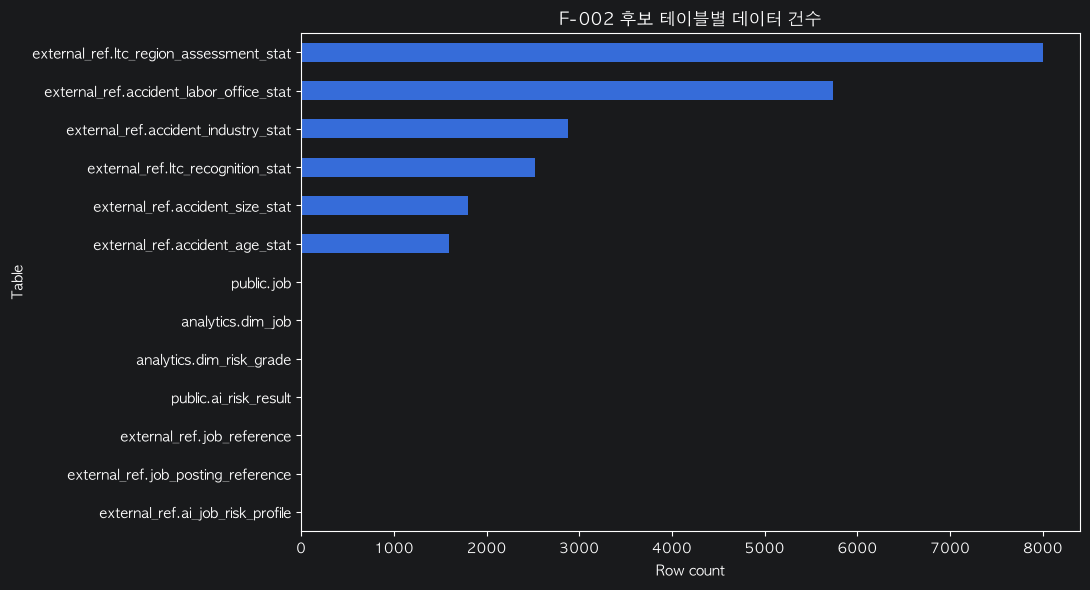

In [4]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 설치된 한글 폰트를 찾아 적용 (없으면 경고만 출력)
installed = {f.name for f in font_manager.fontManager.ttflist}
korean_font = next(
    (
        name for name in (
            "AppleGothic", "Apple SD Gothic Neo",
            "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR",
        )
        if name in installed
    ),
    None,
)

if korean_font:
    plt.rcParams["font.family"] = korean_font
else:
    print("한글 폰트를 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.")

plt.rcParams["axes.unicode_minus"] = False

plot_df = table_summary.dropna(subset=["rows"]).copy()
plot_df["rows"] = plot_df["rows"].astype(int)
plot_df["name"] = plot_df["schema"] + "." + plot_df["table"]

plot_df = plot_df.sort_values("rows")

ax = plot_df.plot.barh(
    x="name",
    y="rows",
    figsize=(11, 6),
    legend=False,
    title="F-002 후보 테이블별 데이터 건수",
)

ax.set_xlabel("Row count")
ax.set_ylabel("Table")
plt.tight_layout()
plt.show()

## Notebook Cell 04 — 실제 컬럼과 샘플 확인


In [5]:

from sqlalchemy import inspect, text
from IPython.display import display
import pandas as pd

target_tables = [
    "accident_age_stat",
    "accident_industry_stat",
    "accident_size_stat",
    "accident_labor_office_stat",
    "ltc_recognition_stat",
    "ltc_region_assessment_stat",
]

inspector = inspect(engine)
all_columns = []

for table_name in target_tables:
    print("\n" + "=" * 70)
    print(f"external_ref.{table_name}")

    # 컬럼 메타데이터 확인
    columns = inspector.get_columns(
        table_name,
        schema="external_ref",
    )

    for column in columns:
        all_columns.append({
            "table": table_name,
            "column": column["name"],
            "type": str(column["type"]),
            "nullable": column["nullable"],
        })

    # 테이블명은 위의 고정 목록에서만 사용
    query = text(
        f'SELECT * FROM "external_ref"."{table_name}" LIMIT 3'
    )

    with engine.connect() as conn:
        sample = pd.read_sql(query, conn)

    display(sample)

# 전체 컬럼 매핑
column_map = pd.DataFrame(all_columns)

print("\n전체 컬럼 매핑")
display(column_map)
=


external_ref.accident_age_stat


,id,source_period,statistic_year,age_group,accident_category,metric_name,metric_value,source_endpoint,source_row,collected_at
0,1,2021,2004,50세 ~ 54세,None,재해자수,10013.0,https://api.odcloud.kr/api/15064486/v1/uddi:f2...,"{'2004': '10013.0', '2005': '10236.0', '2006':...",2026-10-08 15:52:59.457372+00:00
1,2,2021,2005,50세 ~ 54세,None,재해자수,10236.0,https://api.odcloud.kr/api/15064486/v1/uddi:f2...,"{'2004': '10013.0', '2005': '10236.0', '2006':...",2026-10-08 15:52:59.457372+00:00
2,3,2021,2006,50세 ~ 54세,None,재해자수,11363.0,https://api.odcloud.kr/api/15064486/v1/uddi:f2...,"{'2004': '10013.0', '2005': '10236.0', '2006':...",2026-10-08 15:52:59.457372+00:00



external_ref.accident_industry_stat


,id,source_period,statistic_year,industry_major,industry_middle,accident_category,metric_name,metric_value,source_endpoint,source_row,collected_at
0,1,2020,2004,건설업,건설업,사고재해,사고재해자수,18856.0,https://api.odcloud.kr/api/15084656/v1/uddi:79...,"{'구분': '건설업', '대업종': '건설업', '_dataset_code': '...",2026-10-08 16:02:00.707080+00:00
1,2,2020,2005,건설업,건설업,사고재해,사고재해자수,15954.0,https://api.odcloud.kr/api/15084656/v1/uddi:79...,"{'구분': '건설업', '대업종': '건설업', '_dataset_code': '...",2026-10-08 16:02:00.707080+00:00
2,3,2020,2006,건설업,건설업,사고재해,사고재해자수,17577.0,https://api.odcloud.kr/api/15084656/v1/uddi:79...,"{'구분': '건설업', '대업종': '건설업', '_dataset_code': '...",2026-10-08 16:02:00.707080+00:00



external_ref.accident_size_stat


...

,id,source_period,category_1,category_2,care_grade,metric_name,metric_value,unit,source_endpoint,source_row,collected_at
0,1,2021,2010년,비율,1등급,장기요양 인정현황,10.1,%,https://api.odcloud.kr/api/3051420/v1/uddi:b48...,"{'1등급': 10.1, '2등급': 15.8, '3등급': 41.9, '4등급':...",2026-10-08 15:48:56.152687+00:00
1,2,2021,2010년,비율,2등급,장기요양 인정현황,15.8,%,https://api.odcloud.kr/api/3051420/v1/uddi:b48...,"{'1등급': 10.1, '2등급': 15.8, '3등급': 41.9, '4등급':...",2026-10-08 15:48:56.152687+00:00
2,3,2021,2010년,비율,3등급,장기요양 인정현황,41.9,%,https://api.odcloud.kr/api/3051420/v1/uddi:b48...,"{'1등급': 10.1, '2등급': 15.8, '3등급': 41.9, '4등급':...",2026-10-08 15:48:56.152687+00:00



external_ref.ltc_region_assessment_stat


,id,source_period,region_name,gender,qualification,assessment_grade,assessed_count,source_endpoint,source_row,collected_at
0,1,2021,인천광역시,여자,기초,인지지원등급,67,https://api.odcloud.kr/api/15072696/v1/uddi:63...,"{'성별': '여자', '시도': '인천광역시', '자격': '기초', '판정등급'...",2026-10-08 16:19:27.794636+00:00
1,2,2021,충청북도,여자,기초,등급외,679,https://api.odcloud.kr/api/15072696/v1/uddi:63...,"{'성별': '여자', '시도': '충청북도', '자격': '기초', '판정등급':...",2026-10-08 16:19:27.794636+00:00
2,3,2021,전라남도,여자,일반,등급외,6836,https://api.odcloud.kr/api/15072696/v1/uddi:63...,"{'성별': '여자', '시도': '전라남도', '자격': '일반', '판정등급':...",2026-10-08 16:19:27.794636+00:00



전체 컬럼 매핑


,table,column,type,nullable
0,accident_age_stat,id,BIGINT,False
1,accident_age_stat,source_period,VARCHAR(20),False
2,accident_age_stat,statistic_year,INTEGER,True
3,accident_age_stat,age_group,VARCHAR(100),True
4,accident_age_stat,accident_category,VARCHAR(200),True
...,...,...,...,...
59,ltc_region_assessment_stat,assessment_grade,VARCHAR(100),True
60,ltc_region_assessment_stat,assessed_count,BIGINT,True
61,ltc_region_assessment_stat,source_endpoint,TEXT,True
62,ltc_region_assessment_stat,source_row,JSONB,False


## Notebook Cell 05 — 연도·지표·중복·결측 분석


=== 데이터 품질 요약 ===


,table,rows,null_values,invalid_metric,negative_metric,duplicate_key_candidates,unique_keys
0,accident_age_stat,1599,1599,0,0,1249,350
1,accident_industry_stat,2880,0,0,0,2160,720
2,accident_size_stat,1800,0,0,0,0,1800
3,accident_labor_office_stat,5733,11466,0,0,4655,1078
4,ltc_recognition_stat,2520,530,218,0,288,2232
5,ltc_region_assessment_stat,8001,0,0,0,56,7945


=== 지표 종류 및 단위 ===


,table,metric_name,rows
0,accident_age_stat,재해자수,1599


,table,metric_name,rows
0,accident_industry_stat,사고재해자수,2880


...

,table,statistic_year,age_group,accident_category,metric_name,metric_value
0,accident_age_stat,2004,50세 ~ 54세,None,재해자수,10013.0
1,accident_age_stat,2005,50세 ~ 54세,None,재해자수,10236.0
2,accident_age_stat,2006,50세 ~ 54세,None,재해자수,11363.0
3,accident_age_stat,2007,50세 ~ 54세,None,재해자수,12386.0
4,accident_age_stat,2008,50세 ~ 54세,None,재해자수,14015.0
5,accident_age_stat,2009,50세 ~ 54세,None,재해자수,14942.0
6,accident_age_stat,2010,50세 ~ 54세,None,재해자수,15976.0
7,accident_age_stat,2011,50세 ~ 54세,None,재해자수,15694.0
8,accident_age_stat,2012,50세 ~ 54세,None,재해자수,15663.0
9,accident_age_stat,2013,50세 ~ 54세,None,재해자수,15473.0


,table,statistic_year,industry_major,industry_middle,accident_category,metric_name,metric_value
0,accident_industry_stat,2004,건설업,건설업,사고재해,사고재해자수,18856.0
1,accident_industry_stat,2005,건설업,건설업,사고재해,사고재해자수,15954.0
2,accident_industry_stat,2006,건설업,건설업,사고재해,사고재해자수,17577.0
3,accident_industry_stat,2007,건설업,건설업,사고재해,사고재해자수,18419.0
4,accident_industry_stat,2008,건설업,건설업,사고재해,사고재해자수,20088.0
5,accident_industry_stat,2009,건설업,건설업,사고재해,사고재해자수,20267.0
6,accident_industry_stat,2010,건설업,건설업,사고재해,사고재해자수,21885.0
7,accident_industry_stat,2011,건설업,건설업,사고재해,사고재해자수,22187.0
8,accident_industry_stat,2012,건설업,건설업,사고재해,사고재해자수,22679.0
9,accident_industry_stat,2013,건설업,건설업,사고재해,사고재해자수,22892.0


,table,statistic_year,labor_office,region_name,accident_category,metric_name,metric_value
0,accident_labor_office_stat,2004,서산,None,None,재해자수,0.0
1,accident_labor_office_stat,2005,서산,None,None,재해자수,0.0
2,accident_labor_office_stat,2006,서산,None,None,재해자수,0.0
3,accident_labor_office_stat,2007,서산,None,None,재해자수,0.0
4,accident_labor_office_stat,2008,서산,None,None,재해자수,0.0
5,accident_labor_office_stat,2009,서산,None,None,재해자수,0.0
6,accident_labor_office_stat,2010,서산,None,None,재해자수,0.0
7,accident_labor_office_stat,2011,서산,None,None,재해자수,0.0
8,accident_labor_office_stat,2012,서산,None,None,재해자수,0.0
9,accident_labor_office_stat,2013,서산,None,None,재해자수,0.0


,table,source_period,category_1,category_2,care_grade,metric_name,unit,metric_value
96,ltc_recognition_stat,2020,NaN,비율,1등급,장기요양 인정현황,%,10.1
97,ltc_recognition_stat,2020,NaN,비율,2등급,장기요양 인정현황,%,15.8
98,ltc_recognition_stat,2020,NaN,비율,3등급,장기요양 인정현황,%,41.9
99,ltc_recognition_stat,2020,NaN,비율,4등급,장기요양 인정현황,%,NaN
100,ltc_recognition_stat,2020,NaN,비율,5등급,장기요양 인정현황,%,NaN
101,ltc_recognition_stat,2020,NaN,비율,전체계,장기요양 인정현황,%,NaN
102,ltc_recognition_stat,2020,NaN,비율,등급외a,장기요양 인정현황,%,19.8
103,ltc_recognition_stat,2020,NaN,비율,등급외b,장기요양 인정현황,%,8.7
104,ltc_recognition_stat,2020,NaN,비율,등급외c,장기요양 인정현황,%,3.7
105,ltc_recognition_stat,2020,NaN,비율,인정자소계,장기요양 인정현황,%,NaN


,table,source_period,region_name,gender,qualification,assessment_grade,assessed_count
1371,ltc_region_assessment_stat,2024,대전,남자,일반,인지지원등급,104
1377,ltc_region_assessment_stat,2024,대전,남자,의료급여,등급외,11
1387,ltc_region_assessment_stat,2024,대전,여자,감경,인지지원등급,116
1394,ltc_region_assessment_stat,2024,대전,남자,일반,등급외,1214
1396,ltc_region_assessment_stat,2024,대전,여자,감경,인지지원등급,129
1405,ltc_region_assessment_stat,2024,대전,여자,감경,등급외,135
1428,ltc_region_assessment_stat,2024,대전,여자,일반,등급외,1659
1441,ltc_region_assessment_stat,2024,대전,남자,의료급여,인지지원등급,2
1442,ltc_region_assessment_stat,2024,대전,남자,의료급여,인지지원등급,2
1445,ltc_region_assessment_stat,2024,대전,여자,의료급여,인지지원등급,2


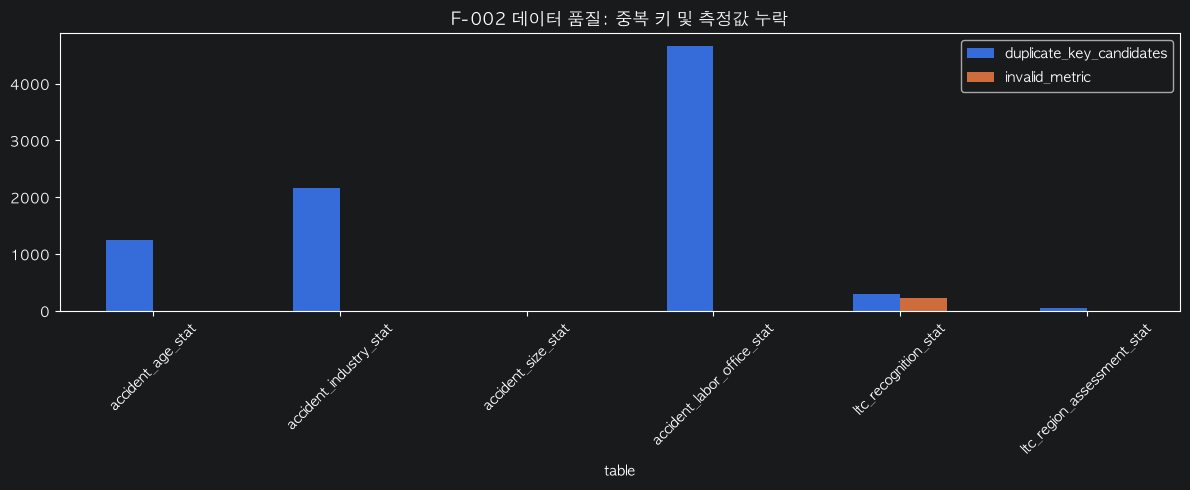

In [6]:

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text
from IPython.display import display

# F-002 공공데이터 6개 테이블
target_tables = [
    "accident_age_stat",
    "accident_industry_stat",
    "accident_size_stat",
    "accident_labor_office_stat",
    "ltc_recognition_stat",
    "ltc_region_assessment_stat",
]

# 테이블별 실제 집계 단위 후보
group_keys = {
    "accident_age_stat": [
        "statistic_year", "age_group",
        "accident_category", "metric_name"
    ],
    "accident_industry_stat": [
        "statistic_year", "industry_major",
        "industry_middle", "accident_category",
        "metric_name"
    ],
    "accident_size_stat": [
        "statistic_year", "industry_major",
        "industry_middle", "company_size",
        "metric_name"
    ],
    "accident_labor_office_stat": [
        "statistic_year", "labor_office",
        "region_name", "accident_category",
        "metric_name"
    ],
    "ltc_recognition_stat": [
        "source_period", "category_1",
        "category_2", "care_grade",
        "metric_name", "unit"
    ],
    "ltc_region_assessment_stat": [
        "source_period", "region_name",
        "gender", "qualification",
        "assessment_grade"
    ],
}

datasets = {}
quality = []
metrics = []
duplicates = []

for name in target_tables:
    query = text(
        f'SELECT * FROM "external_ref"."{name}"'
    )

    with engine.connect() as conn:
        df = pd.read_sql(query, conn)

    datasets[name] = df

    # 수치형 측정값 검증
    value_col = (
        "metric_value"
        if "metric_value" in df.columns
        else "assessed_count"
    )

    values = pd.to_numeric(
        df[value_col], errors="coerce"
    )

    # 업무 집계 단위별 중복 후보
    keys = [
        col for col in group_keys[name]
        if col in df.columns
    ]

    duplicate_count = int(
        df.duplicated(subset=keys).sum()
    )

    # 원본 수치와 NULL 품질 확인
    quality.append({
        "table": name,
        "rows": len(df),
        "null_values": int(df.isna().sum().sum()),
        "invalid_metric": int(values.isna().sum()),
        "negative_metric": int((values < 0).sum()),
        "duplicate_key_candidates": duplicate_count,
        "unique_keys": df[keys].drop_duplicates().shape[0],
    })

    # 지표의 종류와 단위 파악
    dimensions = [
        col for col in ["metric_name", "unit"]
        if col in df.columns
    ]

    if dimensions:
        counts = (
            df.groupby(dimensions, dropna=False)
              .size()
              .reset_index(name="rows")
        )
        counts.insert(0, "table", name)
        metrics.append(counts)

    # 중복된 집계 키 샘플
    if duplicate_count:
        example = df.loc[
            df.duplicated(subset=keys, keep=False),
            keys + [value_col]
        ].head(10).copy()

        example.insert(0, "table", name)
        duplicates.append(example)

quality_report = pd.DataFrame(quality)

print("=== 데이터 품질 요약 ===")
display(quality_report)

print("=== 지표 종류 및 단위 ===")
for metric_table in metrics:
    display(metric_table)

print("=== 집계 키 중복 후보 ===")
if duplicates:
    for sample in duplicates:
        display(sample)
else:
    print("지정한 집계 키 기준 중복 후보 없음")

# 시각화
ax = quality_report.plot.bar(
    x="table",
    y=["duplicate_key_candidates", "invalid_metric"],
    figsize=(12, 5),
    rot=45,
    title="F-002 데이터 품질: 중복 키 및 측정값 누락",
)
plt.tight_layout()
plt.show()


## Notebook Cell 06 — accident_size_stat 재해율 계산 가능성 검증

In [7]:

import pandas as pd
from IPython.display import display

df = datasets["accident_size_stat"].copy()

keys = [
    "statistic_year",
    "industry_major",
    "industry_middle",
    "company_size",
]

# 1. 연도별 측정 지표 건수
print("=== 연도별 지표 분포 ===")
display(
    df.groupby(
        ["statistic_year", "metric_name"],
        dropna=False
    ).size().unstack(fill_value=0)
)

# 2. 측정 지표별 출처 및 중복 여부
print("=== 측정 지표별 출처 ===")
display(
    df.groupby(
        ["source_period", "metric_name", "source_endpoint"],
        dropna=False
    ).agg(
        rows=("id", "size"),
        years=("statistic_year", "nunique"),
        groups=("company_size", "nunique")
    ).reset_index()
)

# 3. 같은 집계 키 + 지표에 여러 행이 있는지 확인
metric_keys = keys + ["metric_name"]

dup_summary = (
    df.groupby(metric_keys, dropna=False)
    .agg(
        rows=("id", "size"),
        unique_values=("metric_value", "nunique")
    )
    .reset_index()
)

print("=== 중복 측정값 그룹 ===")
display(dup_summary[dup_summary["rows"] > 1].head(30))

# 4. 집계 키당 지표가 유일할 때만 넓은 표로 변환
if (dup_summary["rows"] > 1).any():
    print("집계 키 중복 발견: 출처·집계 기준 확인 전 피벗 중단")
else:
    wide = df.pivot(
        index=keys,
        columns="metric_name",
        values="metric_value"
    ).reset_index()

    for col in ["근로자수", "사업장수", "재해자수"]:
        if col not in wide.columns:
            wide[col] = float("nan")

    ready = wide[
        (wide["근로자수"] > 0)
        & wide["재해자수"].notna()
    ].copy()

    # 근로자 1,000명당 재해자수.
    # 공식 산업재해 발생률과 구별하기 위해
    # 탐색용 지표로만 사용한다.
    ready["injured_per_1000_workers"] = (
        ready["재해자수"] / ready["근로자수"] * 1000
    )

    print("집계 키 조합:", len(wide))
    print("분모·분자 대응 가능 조합:", len(ready))

    display(
        ready[
            keys + [
                "근로자수",
                "재해자수",
                "injured_per_1000_workers"
            ]
        ].head(20)
    )


=== 연도별 지표 분포 ===


metric_name,근로자수,사업장수,재해자수
statistic_year,,,
2020,0,0,300
2021,0,0,300
2022,0,0,300
2023,0,0,300
2024,0,300,0
2025,300,0,0


=== 측정 지표별 출처 ===


,source_period,metric_name,source_endpoint,rows,years,groups
0,2020,재해자수,https://api.odcloud.kr/api/15064490/v1/uddi:c9...,300,1,10
1,2021,재해자수,https://api.odcloud.kr/api/15064490/v1/uddi:39...,300,1,10
2,2022,재해자수,https://api.odcloud.kr/api/15064490/v1/uddi:51...,300,1,10
3,2023,재해자수,https://api.odcloud.kr/api/15064490/v1/uddi:1e...,300,1,10
4,2024,사업장수,https://api.odcloud.kr/api/15064490/v1/uddi:89...,300,1,10
5,2025,근로자수,https://api.odcloud.kr/api/15064490/v1/uddi:5b...,300,1,10


=== 중복 측정값 그룹 ===


,statistic_year,industry_major,industry_middle,company_size,metric_name,rows,unique_values


집계 키 조합: 1800
분모·분자 대응 가능 조합: 0


metric_name,statistic_year,industry_major,industry_middle,company_size,근로자수,재해자수,injured_per_1000_workers


## Notebook Cell 07 — 중복 후보 원인 진단

In [8]:

from IPython.display import display

audit_targets = {
    "accident_age_stat": [
        "statistic_year", "age_group", "metric_name"
    ],
    "accident_industry_stat": [
        "statistic_year", "industry_major",
        "industry_middle", "accident_category",
        "metric_name"
    ],
    "accident_labor_office_stat": [
        "statistic_year", "labor_office",
        "metric_name"
    ],
}

for name, keys in audit_targets.items():
    df = datasets[name].copy()

    audit = (
        df.groupby(keys, dropna=False)
        .agg(
            rows=("id", "size"),
            source_periods=("source_period", "nunique"),
            endpoints=("source_endpoint", "nunique"),
            distinct_values=("metric_value", "nunique"),
            min_value=("metric_value", "min"),
            max_value=("metric_value", "max"),
        )
        .reset_index()
    )

    repeated = audit[audit["rows"] > 1].copy()

    print(f"\n=== {name} ===")
    print("중복 키 그룹 수:", len(repeated))
    print(
        "측정값이 다른 중복 그룹:",
        int((repeated["distinct_values"] > 1).sum())
    )
    print(
        "출처가 다른 중복 그룹:",
        int((repeated["endpoints"] > 1).sum())
    )

    display(
        repeated.sort_values(
            "rows", ascending=False
        ).head(10)
    )



=== accident_age_stat ===
중복 키 그룹 수: 334
측정값이 다른 중복 그룹: 0
출처가 다른 중복 그룹: 334


,statistic_year,age_group,metric_name,rows,source_periods,endpoints,distinct_values,min_value,max_value
0,2004,18세 ~ 24세,재해자수,6,6,6,1,4037.0,4037.0
166,2014,45세 ~ 49세,재해자수,6,6,6,1,11918.0,11918.0
150,2013,45세 ~ 49세,재해자수,6,6,6,1,12238.0,12238.0
151,2013,50세 ~ 54세,재해자수,6,6,6,1,15473.0,15473.0
152,2013,55세 ~ 59세,재해자수,6,6,6,1,14478.0,14478.0
159,2013,분류불능,재해자수,6,6,6,1,0.0,0.0
160,2014,18세 ~ 24세,재해자수,6,6,6,1,3659.0,3659.0
161,2014,18세 미만,재해자수,6,6,6,1,94.0,94.0
162,2014,25세 ~ 29세,재해자수,6,6,6,1,4679.0,4679.0
163,2014,30세 ~ 34세,재해자수,6,6,6,1,6370.0,6370.0



=== accident_industry_stat ===
중복 키 그룹 수: 610
측정값이 다른 중복 그룹: 12
출처가 다른 중복 그룹: 610


,statistic_year,industry_major,industry_middle,accident_category,metric_name,rows,source_periods,endpoints,distinct_values,min_value,max_value
0,2004,건설업,건설업,사고재해,사고재해자수,5,5,5,1,18856.0,18856.0
375,2014,제조업,목재및종이제품제조업,사고재해,사고재해자수,5,5,5,1,1636.0,1636.0
389,2015,기타의사업,국가및지방자치단체의사업,사고재해,사고재해자수,5,5,5,1,179.0,179.0
388,2015,금융및보험업,금융및보험업,사고재해,사고재해자수,5,5,5,1,258.0,258.0
387,2015,광 업,석회석·금속·비금속광업및기타광업,사고재해,사고재해자수,5,5,5,1,111.0,111.0
386,2015,광 업,석탄광업및채석업,사고재해,사고재해자수,5,5,5,1,34.0,34.0
385,2015,건설업,건설업,사고재해,사고재해자수,5,5,5,1,24287.0,24287.0
384,2014,제조업,화학및고무제품제조업,사고재해,사고재해자수,5,5,5,1,2888.0,2888.0
381,2014,제조업,전기기계기구·정밀기구·전자제품제조업,사고재해,사고재해자수,5,5,5,1,1557.0,1557.0
380,2014,제조업,의약품·화장품·연탄·석유제품제조업,사고재해,사고재해자수,5,5,5,1,144.0,144.0



=== accident_labor_office_stat ===
중복 키 그룹 수: 1029
측정값이 다른 중복 그룹: 0
출처가 다른 중복 그룹: 1029


,statistic_year,labor_office,metric_name,rows,source_periods,endpoints,distinct_values,min_value,max_value
0,2004,강릉,재해자수,6,6,6,1,929.0,929.0
625,2016,전주,재해자수,6,6,6,1,1822.0,1822.0
549,2015,목포,재해자수,6,6,6,1,1215.0,1215.0
550,2015,보령,재해자수,6,6,6,1,1317.0,1317.0
551,2015,부산동부,재해자수,6,6,6,1,1461.0,1461.0
552,2015,부산북부,재해자수,6,6,6,1,1882.0,1882.0
553,2015,부산청,재해자수,6,6,6,1,2200.0,2200.0
554,2015,부천,재해자수,6,6,6,1,2341.0,2341.0
555,2015,서산,재해자수,6,6,6,1,0.0,0.0
556,2015,서울강남,재해자수,6,6,6,1,1337.0,1337.0


## Notebook Cell 08 — 연도별 데이터 범위 검증

In [9]:
import pandas as pd
from IPython.display import display

df = datasets["accident_size_stat"].copy()

# 연도·측정값별 관측 건수와 총합
year_summary = (
    df.groupby(
        ["statistic_year", "metric_name"],
        dropna=False
    )
    .agg(
        rows=("id", "count"),
        total=("metric_value", "sum"),
        min_value=("metric_value", "min"),
        max_value=("metric_value", "max")
    )
    .reset_index()
)

print("=== 연도별 측정값 현황 ===")
display(year_summary)

# 어떤 연도에 근로자수·재해자수가 함께 있는지
coverage = (
    year_summary.pivot(
        index="statistic_year",
        columns="metric_name",
        values="rows"
    )
    .fillna(0)
    .astype(int)
)

print("=== 연도별 지표 보유 현황 ===")
display(coverage)

required = {"근로자수", "재해자수"}

if required.issubset(coverage.columns):
    eligible_years = coverage.index[
        (coverage["근로자수"] > 0)
        & (coverage["재해자수"] > 0)
    ].tolist()

    print("두 지표가 모두 존재하는 연도:", eligible_years)
else:
    print("재해율 계산에 필요한 지표가 부족합니다.")

=== 연도별 측정값 현황 ===


,statistic_year,metric_name,rows,total,min_value,max_value
0,2020,재해자수,300,108379.0,0.0,10815.0
1,2021,재해자수,300,122713.0,0.0,12259.0
2,2022,재해자수,300,130348.0,0.0,11522.0
3,2023,재해자수,300,136796.0,0.0,10228.0
4,2024,사업장수,300,142771.0,0.0,10460.0
5,2025,근로자수,300,147130.0,0.0,10876.0


=== 연도별 지표 보유 현황 ===


metric_name,근로자수,사업장수,재해자수
statistic_year,,,
2020,0,0,300
2021,0,0,300
2022,0,0,300
2023,0,0,300
2024,0,300,0
2025,300,0,0


두 지표가 모두 존재하는 연도: []


## Notebook Cell 09 — 계산 가능한 조합만 추출

In [10]:
import pandas as pd
from IPython.display import display

df = datasets["accident_size_stat"].copy()

keys = [
    "statistic_year",
    "industry_major",
    "industry_middle",
    "company_size",
]

required_metrics = ["근로자수", "재해자수"]

# 같은 집계 키·측정 지표에 중복 행이 있다면
# 임의로 합산하지 않고 제외
key_metrics = keys + ["metric_name"]

counts = (
    df.groupby(key_metrics, dropna=False)
    .size()
    .reset_index(name="record_count")
)

unique_combinations = counts[
    counts["record_count"] == 1
][key_metrics]

# 중복 없는 조합만 유지
clean = df.merge(
    unique_combinations,
    on=key_metrics,
    how="inner",
)

# 숫자 변환
clean["metric_value"] = pd.to_numeric(
    clean["metric_value"],
    errors="coerce",
)

# 집계 기준별 행이 중복되지 않으므로 pivot 가능
wide = clean.pivot(
    index=keys,
    columns="metric_name",
    values="metric_value",
).reset_index()

wide.columns.name = None

# 측정값이 없는 경우에도 확인할 수 있도록 컬럼 생성
for metric in required_metrics:
    if metric not in wide.columns:
        wide[metric] = float("nan")

# 분모·분자가 모두 있는 조합
ready = wide[
    wide["근로자수"].gt(0)
    & wide["재해자수"].notna()
].copy()

# 탐색용 근로자 1,000명당 재해자수
ready["injured_per_1000_workers"] = (
    ready["재해자수"]
    / ready["근로자수"]
    * 1000
)

print("전체 집계 조합:", len(wide))
print("계산 가능 조합:", len(ready))

display(
    ready[
        keys + [
            "근로자수",
            "재해자수",
            "injured_per_1000_workers",
        ]
    ].head(20)
)

전체 집계 조합: 1800
계산 가능 조합: 0


,statistic_year,industry_major,industry_middle,company_size,근로자수,재해자수,injured_per_1000_workers


## Notebook Cell 10 — 계산 가능 여부 시각화

,status,count
0,All combinations,1800
1,Matched numerator / denominator,0


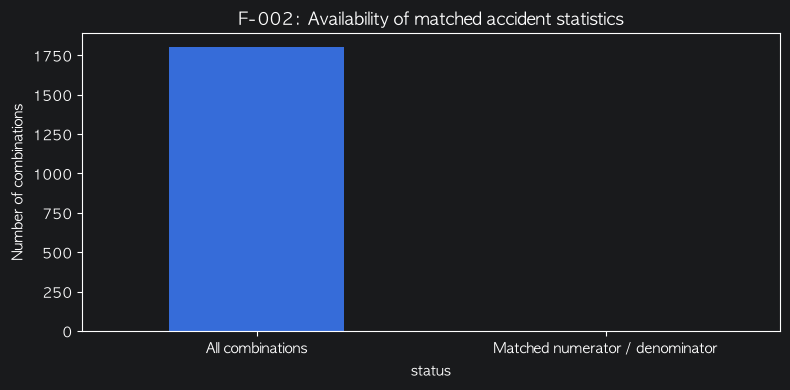

분자·분모를 연결할 수 있는 조합이 없습니다. 출처와 집계 기준을 먼저 검토해야 합니다.


In [11]:
import matplotlib.pyplot as plt

summary = pd.DataFrame({
    "status": [
        "All combinations",
        "Matched numerator / denominator",
    ],
    "count": [len(wide), len(ready)],
})

display(summary)

ax = summary.plot.bar(
    x="status",
    y="count",
    legend=False,
    figsize=(8, 4),
    title="F-002: Availability of matched accident statistics",
)

ax.set_ylabel("Number of combinations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

if not ready.empty:
    display(
        ready[
            keys + ["injured_per_1000_workers"]
        ].sort_values(
            "injured_per_1000_workers",
            ascending=False,
        ).head(10)
    )
else:
    print(
        "분자·분모를 연결할 수 있는 조합이 없습니다. "
        "출처와 집계 기준을 먼저 검토해야 합니다."
    )

## Notebook Cell 11 — ETL 연도 매핑 오류 확인

In [12]:
import pandas as pd
import json
from IPython.display import display

df = datasets["accident_size_stat"].copy()

# 연도·지표별 원본 샘플 확인
samples = (
    df.sort_values("id")
    .groupby(
        ["statistic_year", "metric_name"],
        group_keys=False
    )
    .head(1)
    .copy()
)

def extract_source_info(value):
    if isinstance(value, dict):
        source = value
    elif isinstance(value, str):
        try:
            source = json.loads(value)
        except json.JSONDecodeError:
            return {"parse_error": True}
    else:
        return {}

    return {
        "original_keys": list(source.keys()),
        "year_fields": {
            k: v
            for k, v in source.items()
            if "연도" in k
            or "년도" in k
            or "year" in k.lower()
        },
        "sample_values": {
            k: v
            for k, v in list(source.items())[:8]
        },
    }

samples["original_info"] = (
    samples["source_row"].apply(extract_source_info)
)

display(
    samples[
        [
            "source_period",
            "statistic_year",
            "metric_name",
            "industry_major",
            "industry_middle",
            "company_size",
            "metric_value",
            "source_endpoint",
            "original_info",
        ]
    ].to_dict("records")
)

# 동일한 집계 단위가 서로 다른 연도에 있는지
keys = [
    "industry_major",
    "industry_middle",
    "company_size",
]

coverage = (
    df.groupby(keys + ["metric_name"])
    ["statistic_year"]
    .agg(
        ["min", "max", "nunique"]
    )
    .reset_index()
)

display(coverage.head(20))

[{'source_period': '2024',
  'statistic_year': 2024,
  'metric_name': '사업장수',
  'industry_major': '광  업',
  'industry_middle': '석회석·금속·비금속광업및기타광업',
  'company_size': '20~29인',
  'metric_value': 66.0,
  'source_endpoint': 'https://api.odcloud.kr/api/15064490/v1/uddi:895c950e-dd0e-4968-ab1a-ee6183f59b0b',
  'original_info': {'original_keys': ['구분',
    '5인-9인',
    '대업종',
    '10인-19인',
    '20인-29인',
    '30인-49인',
    '50인-99인',
    '5인 미만',
    '_metric_name',
    '100인-299인',
    '300인-499인',
    '500인-999인',
    '_company_size',
    '_dataset_code',
    'source_period',
    '1000인 이상',
    'source_dataset',
    '1,000인 이상',
    'source_endpoint',
    '_source_row_number',
    '5인-9인 사업장수',
    '10인-19인 사업장수',
    '20인-29인 사업장수',
    '30인-49인 사업장수',
    '50인-99인 사업장수',
    '5인 - 9인 근로자수',
    '5인 미만 근로자수',
    '5인 미만 사업장수',
    '1000인 이상사업장수',
    '100인-299인 사업장수',
    '10인 - 19인 근로자수',
    '20인 - 29인 근로자수',
    '300인-499인 사업장수',
    '30인 - 49인 근로자수',
    '500인-999인 사업장수',
    '50인 -

,industry_major,industry_middle,company_size,metric_name,min,max,nunique
0,건설업,건설업,"1,000인 이상",근로자수,2025,2025,1
1,건설업,건설업,"1,000인 이상",사업장수,2024,2024,1
2,건설업,건설업,"1,000인 이상",재해자수,2020,2023,4
3,건설업,건설업,100~299인,근로자수,2025,2025,1
4,건설업,건설업,100~299인,사업장수,2024,2024,1
5,건설업,건설업,100~299인,재해자수,2020,2023,4
6,건설업,건설업,10~19인,근로자수,2025,2025,1
7,건설업,건설업,10~19인,사업장수,2024,2024,1
8,건설업,건설업,10~19인,재해자수,2020,2023,4
9,건설업,건설업,20~29인,근로자수,2025,2025,1


## Notebook Cell 12 — 원본값과 DB 적재값 대조

In [13]:

import pandas as pd
import re
from IPython.display import display

df = datasets["accident_size_stat"].copy()

# 회사 규모 표기를 정규화하여 비교
def normalize_size(value):
    return re.sub(r"[\s,\-~]", "", str(value or ""))

def matching_original_columns(row):
    raw = row["source_row"]

    if not isinstance(raw, dict):
        return []

    size = normalize_size(row["company_size"])
    metric = row["metric_name"]

    matches = []

    for key, value in raw.items():
        key_norm = normalize_size(key)

        # 원본 컬럼 중 지표 이름과 규모를 모두 가진 컬럼
        if metric in key_norm and size in key_norm:
            matches.append({
                "column": key,
                "raw_value": value,
            })

    return matches

df["raw_matches"] = df.apply(
    matching_original_columns,
    axis=1,
)

# 첫 번째 일치 컬럼의 값과 DB 값 비교
def compare_values(row):
    matches = row["raw_matches"]

    if len(matches) != 1:
        return "NEEDS_REVIEW"

    raw_value = pd.to_numeric(
        matches[0]["raw_value"],
        errors="coerce",
    )

    db_value = pd.to_numeric(
        row["metric_value"],
        errors="coerce",
    )

    if pd.isna(raw_value) or pd.isna(db_value):
        return "MISSING"

    return (
        "MATCH"
        if abs(raw_value - db_value) < 1e-9
        else "MISMATCH"
    )

df["comparison"] = df.apply(compare_values, axis=1)

print("=== 원본값과 적재값 비교 ===")
display(
    df.groupby(
        ["source_period", "metric_name", "comparison"],
        dropna=False
    )
    .size()
    .reset_index(name="rows")
)

print("=== 점검이 필요한 행 ===")
display(
    df.loc[
        df["comparison"] != "MATCH",
        [
            "source_period",
            "statistic_year",
            "metric_name",
            "company_size",
            "metric_value",
            "raw_matches",
            "comparison",
        ],
    ].head(20)
)


=== 원본값과 적재값 비교 ===


,source_period,metric_name,comparison,rows
0,2020,재해자수,NEEDS_REVIEW,300
1,2021,재해자수,NEEDS_REVIEW,300
2,2022,재해자수,NEEDS_REVIEW,300
3,2023,재해자수,NEEDS_REVIEW,300
4,2024,사업장수,MATCH,60
5,2024,사업장수,NEEDS_REVIEW,240
6,2025,근로자수,MATCH,60
7,2025,근로자수,NEEDS_REVIEW,240


=== 점검이 필요한 행 ===


,source_period,statistic_year,metric_name,company_size,metric_value,raw_matches,comparison
0,2024,2024,사업장수,20~29인,66.0,[],NEEDS_REVIEW
1,2024,2024,사업장수,300~499인,178.0,[],NEEDS_REVIEW
2,2022,2022,재해자수,20~29인,1256.0,[],NEEDS_REVIEW
3,2025,2025,근로자수,20~29인,62.0,[],NEEDS_REVIEW
4,2021,2021,재해자수,30~49인,115.0,[],NEEDS_REVIEW
5,2021,2021,재해자수,20~29인,38.0,[],NEEDS_REVIEW
6,2023,2023,재해자수,20~29인,1346.0,[],NEEDS_REVIEW
7,2022,2022,재해자수,100~299인,400.0,[],NEEDS_REVIEW
9,2020,2020,재해자수,5인 미만,57.0,[],NEEDS_REVIEW
11,2025,2025,근로자수,10~19인,1636.0,[],NEEDS_REVIEW


## Notebook Cell 13 — 원본 컬럼 매핑 수정 및 재검증

In [14]:

import re
import json
import pandas as pd
from IPython.display import display

df = datasets["accident_size_stat"].copy()

def normalize_size(value):
    """20~29인 / 20인-29인 / 20인 - 29인 → 20-29"""
    s = str(value).replace(",", "").strip()

    if "미만" in s:
        numbers = re.findall(r"\d+", s)
        return f"LT-{numbers[0]}" if numbers else None

    if "이상" in s:
        numbers = re.findall(r"\d+", s)
        return f"GE-{numbers[0]}" if numbers else None

    numbers = re.findall(r"\d+", s)
    if len(numbers) == 2:
        return f"{numbers[0]}-{numbers[1]}"

    return None


def to_dict(value):
    if isinstance(value, dict):
        return value

    if isinstance(value, str):
        try:
            return json.loads(value)
        except json.JSONDecodeError:
            return {}

    return {}


def extract_original(row):
    raw = to_dict(row["source_row"])
    metric = row["metric_name"]
    target_size = normalize_size(row["company_size"])

    matches = []

    for key, value in raw.items():
        key_size = normalize_size(key)

        if key_size != target_size or target_size is None:
            continue

        # 재해자수는 원본에서 규모만 있는 컬럼
        if metric == "재해자수":
            # 사업장수·근로자수 컬럼은 제외
            if "사업장수" in key or "근로자수" in key:
                continue

        elif metric not in key:
            continue

        matches.append((key, value))

    if len(matches) == 0:
        return pd.Series([None, None, "COLUMN_NOT_FOUND"])

    if len(matches) > 1:
        return pd.Series([None, None, "AMBIGUOUS"])

    key, value = matches[0]

    return pd.Series([key, value, "FOUND"])


df[["original_column", "original_value", "lookup_status"]] = (
    df.apply(extract_original, axis=1)
)

df["original_numeric"] = pd.to_numeric(
    df["original_value"], errors="coerce"
)

df["db_numeric"] = pd.to_numeric(
    df["metric_value"], errors="coerce"
)

def check_row(row):
    if row["lookup_status"] != "FOUND":
        return row["lookup_status"]

    if pd.isna(row["original_numeric"]):
        return "ORIGINAL_MISSING"

    if pd.isna(row["db_numeric"]):
        return "DB_MISSING"

    if abs(row["original_numeric"] - row["db_numeric"]) < 1e-9:
        return "MATCH"

    return "MISMATCH"


df["validation"] = df.apply(check_row, axis=1)

summary = (
    df.groupby(
        ["source_period", "metric_name", "validation"],
        dropna=False
    )
    .size()
    .reset_index(name="rows")
)

print("=== 원본과 DB 적재값 재검증 ===")
display(summary)

print("=== 일치하지 않거나 확인되지 않은 데이터 ===")
display(
    df.loc[df["validation"] != "MATCH", [
        "source_period",
        "metric_name",
        "company_size",
        "metric_value",
        "original_column",
        "original_value",
        "validation",
    ]].head(30)
)

print("전체:", len(df))
print("일치:", int((df["validation"] == "MATCH").sum()))
print("불일치:", int((df["validation"] == "MISMATCH").sum()))


=== 원본과 DB 적재값 재검증 ===


,source_period,metric_name,validation,rows
0,2020,재해자수,AMBIGUOUS,30
1,2020,재해자수,MATCH,270
2,2021,재해자수,AMBIGUOUS,30
3,2021,재해자수,MATCH,270
4,2022,재해자수,AMBIGUOUS,30
5,2022,재해자수,MATCH,270
6,2023,재해자수,AMBIGUOUS,30
7,2023,재해자수,MATCH,270
8,2024,사업장수,MATCH,300
9,2025,근로자수,MATCH,300


=== 일치하지 않거나 확인되지 않은 데이터 ===


,source_period,metric_name,company_size,metric_value,original_column,original_value,validation
20,2022,재해자수,"1,000인 이상",0.0,NaN,NaN,AMBIGUOUS
35,2020,재해자수,"1,000인 이상",0.0,NaN,NaN,AMBIGUOUS
50,2021,재해자수,"1,000인 이상",1404.0,NaN,NaN,AMBIGUOUS
78,2023,재해자수,"1,000인 이상",44.0,NaN,NaN,AMBIGUOUS
87,2022,재해자수,"1,000인 이상",0.0,NaN,NaN,AMBIGUOUS
107,2023,재해자수,"1,000인 이상",0.0,NaN,NaN,AMBIGUOUS
112,2023,재해자수,"1,000인 이상",159.0,NaN,NaN,AMBIGUOUS
127,2023,재해자수,"1,000인 이상",330.0,NaN,NaN,AMBIGUOUS
130,2020,재해자수,"1,000인 이상",7.0,NaN,NaN,AMBIGUOUS
131,2023,재해자수,"1,000인 이상",289.0,NaN,NaN,AMBIGUOUS


전체: 1800
일치: 1680
불일치: 0


## Notebook Cell 14 — 1,000인 이상 원본값 최종 검증

In [15]:
import pandas as pd
from IPython.display import display

# 기존 df에서 추가 확인이 필요한 120건
ambiguous = df[
    df["validation"] == "AMBIGUOUS"
].copy()

results = []

for idx, row in ambiguous.iterrows():
    raw = to_dict(row["source_row"])

    # 재해자수의 원본 컬럼 후보
    aliases = ["1000인 이상", "1,000인 이상"]

    values = {
        key: pd.to_numeric(raw.get(key), errors="coerce")
        for key in aliases
        if key in raw
    }

    valid_values = [
        float(value)
        for value in values.values()
        if pd.notna(value)
    ]

    db_value = float(row["metric_value"])

    # 원본 후보값이 하나 이상 있고
    # 모든 후보값이 같아야만 검증 통과
    if not valid_values:
        status = "SOURCE_MISSING"
    elif len(set(valid_values)) > 1:
        status = "SOURCE_CONFLICT"
    elif abs(valid_values[0] - db_value) < 1e-9:
        status = "MATCH"
    else:
        status = "MISMATCH"

    results.append({
        "row_index": idx,
        "source_period": row["source_period"],
        "company_size": row["company_size"],
        "db_value": db_value,
        "source_values": values,
        "status": status,
    })

alias_audit = pd.DataFrame(results)

print("=== 1,000인 이상 원본 검증 ===")

display(
    alias_audit.groupby("status")
    .size()
    .reset_index(name="rows")
)

print("=== 검증이 필요한 행 ===")

display(
    alias_audit[
        alias_audit["status"] != "MATCH"
    ].head(20)
)

# 전체 검증 결과 결합
all_status = df["validation"].copy()

for row in results:
    all_status.loc[row["row_index"]] = row["status"]

print("=== 전체 1,800행 검증 결과 ===")

display(
    all_status.value_counts()
    .rename_axis("status")
    .reset_index(name="rows")
)

assert len(df) == 1800

=== 1,000인 이상 원본 검증 ===


,status,rows
0,MATCH,120


=== 검증이 필요한 행 ===


,row_index,source_period,company_size,db_value,source_values,status


=== 전체 1,800행 검증 결과 ===


,status,rows
0,MATCH,1800


## Cell 15: 통계연도 매핑 검증

In [16]:
# Cell 15 — 원본 데이터셋별 메타데이터 확인

import pandas as pd
from IPython.display import display

size_df = datasets["accident_size_stat"].copy()

source_audit = (
    size_df.groupby(
        ["source_endpoint", "source_period",
         "statistic_year", "metric_name"],
        dropna=False
    )
    .agg(
        rows=("id", "size"),
        total=("metric_value", "sum")
    )
    .reset_index()
)

# 원본 source_row에 저장된 데이터셋 식별자 확인
size_df["dataset_code"] = size_df["source_row"].apply(
    lambda x: x.get("_dataset_code")
    if isinstance(x, dict) else None
)

source_audit_codes = (
    size_df.groupby(
        ["source_endpoint", "dataset_code",
         "source_period", "statistic_year", "metric_name"],
        dropna=False
    )
    .size()
    .reset_index(name="rows")
)

display(source_audit_codes)

,source_endpoint,dataset_code,source_period,statistic_year,metric_name,rows
0,https://api.odcloud.kr/api/15064490/v1/uddi:1e...,PUB-009,2023,2023,재해자수,300
1,https://api.odcloud.kr/api/15064490/v1/uddi:39...,PUB-009,2021,2021,재해자수,300
2,https://api.odcloud.kr/api/15064490/v1/uddi:51...,PUB-009,2022,2022,재해자수,300
3,https://api.odcloud.kr/api/15064490/v1/uddi:5b...,PUB-009,2025,2025,근로자수,300
4,https://api.odcloud.kr/api/15064490/v1/uddi:89...,PUB-009,2024,2024,사업장수,300
5,https://api.odcloud.kr/api/15064490/v1/uddi:c9...,PUB-009,2020,2020,재해자수,300


## Notebook Cell 16 — 원본 데이터셋 메타데이터 확인

In [17]:

import pandas as pd
from IPython.display import display

size_df = datasets["accident_size_stat"].copy()

# 원본 JSON에서 메타데이터 추출
def get_raw_value(row, key):
    raw = row["source_row"]
    return raw.get(key) if isinstance(raw, dict) else None

size_df["source_dataset_name"] = size_df.apply(
    lambda row: get_raw_value(row, "source_dataset"),
    axis=1
)

size_df["raw_source_period"] = size_df.apply(
    lambda row: get_raw_value(row, "source_period"),
    axis=1
)

# 실제 API 엔드포인트별 연도·지표·데이터셋 확인
audit = (
    size_df.groupby(
        [
            "source_endpoint",
            "source_dataset_name",
            "source_period",
            "raw_source_period",
            "statistic_year",
            "metric_name",
        ],
        dropna=False
    )
    .agg(
        rows=("id", "size"),
        total_value=("metric_value", "sum"),
    )
    .reset_index()
)

pd.set_option("display.max_colwidth", 150)

print("=== Cell 16: 데이터셋 이름 및 연도 매핑 ===")

display(
    audit[
        [
            "source_dataset_name",
            "source_period",
            "raw_source_period",
            "statistic_year",
            "metric_name",
            "rows",
            "total_value",
            "source_endpoint",
        ]
    ]
)


=== Cell 16: 데이터셋 이름 및 연도 매핑 ===


,source_dataset_name,source_period,raw_source_period,statistic_year,metric_name,rows,total_value,source_endpoint
0,PUB-009_산업규모별_재해자수,2023,2023,2023,재해자수,300,136796.0,https://api.odcloud.kr/api/15064490/v1/uddi:1e446a30-618f-4e6e-8735-a7e5330f2275
1,PUB-009_산업규모별_재해자수,2021,2021,2021,재해자수,300,122713.0,https://api.odcloud.kr/api/15064490/v1/uddi:395f1d49-c4e8-43c1-8234-a921e75661cf
2,PUB-009_산업규모별_재해자수,2022,2022,2022,재해자수,300,130348.0,https://api.odcloud.kr/api/15064490/v1/uddi:516495df-babb-400a-918f-9e9b046aee96
3,PUB-009_산업규모별_재해자수,2025,2025,2025,근로자수,300,147130.0,https://api.odcloud.kr/api/15064490/v1/uddi:5b822baf-2a25-4642-8bc9-d14a2aa458c9
4,PUB-009_산업규모별_재해자수,2024,2024,2024,사업장수,300,142771.0,https://api.odcloud.kr/api/15064490/v1/uddi:895c950e-dd0e-4968-ab1a-ee6183f59b0b
5,PUB-009_산업규모별_재해자수,2020,2020,2020,재해자수,300,108379.0,https://api.odcloud.kr/api/15064490/v1/uddi:c99ee393-2d14-4b2f-99d3-a9ab4a0d63df


## Notebook Cell 17 — 원본에 누락된 지표 탐색

In [18]:
import pandas as pd
import re
from IPython.display import display

size_df = datasets["accident_size_stat"].copy()

# 앞에서 검증한 규모 표기 정규화 함수 재사용
def size_key(value):
    s = str(value).replace(",", "")
    numbers = re.findall(r"\d+", s)

    if "미만" in s and numbers:
        return f"LT-{numbers[0]}"
    if "이상" in s and numbers:
        return f"GE-{numbers[0]}"
    if len(numbers) == 2:
        return f"{numbers[0]}-{numbers[1]}"
    return None


results = []

for _, row in size_df.iterrows():
    if row["metric_name"] != "재해자수":
        continue

    raw = row["source_row"]

    if not isinstance(raw, dict):
        continue

    target = size_key(row["company_size"])

    # 동일한 규모의 근로자수 원본 컬럼 찾기
    matches = [
        (key, value)
        for key, value in raw.items()
        if "근로자수" in key
        and size_key(key) == target
    ]

    numeric = [
        float(value)
        for _, value in matches
        if pd.notna(pd.to_numeric(value, errors="coerce"))
    ]

    if not matches:
        status = "COLUMN_NOT_FOUND"
    elif not numeric:
        status = "VALUE_MISSING"
    elif len(set(numeric)) > 1:
        status = "CONFLICT"
    elif numeric[0] <= 0:
        status = "NONPOSITIVE"
    else:
        status = "AVAILABLE"

    results.append({
        "statistic_year": row["statistic_year"],
        "industry_major": row["industry_major"],
        "industry_middle": row["industry_middle"],
        "company_size": row["company_size"],
        "injured_count": row["metric_value"],
        "worker_count": numeric[0] if status == "AVAILABLE" else None,
        "status": status,
        "source_endpoint": row["source_endpoint"],
    })

worker_audit = pd.DataFrame(results)

print("=== 재해자수 원본의 근로자수 가용성 ===")
display(
    worker_audit.groupby(
        ["statistic_year", "status"]
    ).size().unstack(fill_value=0)
)

print("=== 근로자수 확보 가능 샘플 ===")
display(
    worker_audit[
        worker_audit["status"] == "AVAILABLE"
    ].head(15)
)

=== 재해자수 원본의 근로자수 가용성 ===


status,VALUE_MISSING
statistic_year,
2020,300
2021,300
2022,300
2023,300


=== 근로자수 확보 가능 샘플 ===


,statistic_year,industry_major,industry_middle,company_size,injured_count,worker_count,status,source_endpoint


## Notebook Cell 18 — F-002 산업재해 분석용 데이터셋 생성

In [19]:
import pandas as pd
from IPython.display import display

# 1. 산업재해 업종별 통계
source = datasets["accident_industry_stat"].copy()

keys = [
    "statistic_year",
    "industry_major",
    "industry_middle",
    "accident_category",
    "metric_name",
]

source["metric_value"] = pd.to_numeric(
    source["metric_value"],
    errors="coerce"
)

# 2. 집계 단위별 원본값 일치 검증
audit = (
    source.groupby(keys, dropna=False)
    .agg(
        records=("id", "size"),
        distinct_values=("metric_value", "nunique"),
        accident_count=("metric_value", "first"),
        endpoints=("source_endpoint", "nunique"),
    )
    .reset_index()
)

# 3. 측정값이 유일하고 유효한 그룹만 사용
industry_clean = audit[
    (audit["distinct_values"] == 1)
    & audit["accident_count"].notna()
    & (audit["accident_count"] >= 0)
].copy()

industry_conflicts = audit[
    audit["distinct_values"] != 1
].copy()

print("=== F-002 업종별 분석 데이터 ===")
print("원본 행:", len(source))
print("검증된 집계 그룹:", len(industry_clean))
print("충돌 또는 측정값 누락 그룹:", len(industry_conflicts))

display(industry_clean.head(20))
display(industry_conflicts.head(10))

# 검증 결과 확인
assert not industry_clean.duplicated(subset=keys).any()
assert industry_clean["accident_count"].ge(0).all()

=== F-002 업종별 분석 데이터 ===
원본 행: 2880
검증된 집계 그룹: 708
충돌 또는 측정값 누락 그룹: 12


,statistic_year,industry_major,industry_middle,accident_category,metric_name,records,distinct_values,accident_count,endpoints
0,2004,건설업,건설업,사고재해,사고재해자수,5,1,18856.0,5
3,2004,금융및보험업,금융및보험업,사고재해,사고재해자수,5,1,468.0,5
4,2004,기타의사업,국가및지방자치단체의사업,사고재해,사고재해자수,5,1,0.0,5
5,2004,기타의사업,기타의각종사업,사고재해,사고재해자수,5,1,1930.0,5
6,2004,기타의사업,도소매·음식·숙박업,사고재해,사고재해자수,5,1,8346.0,5
7,2004,기타의사업,부동산업및임대업,사고재해,사고재해자수,5,1,128.0,5
8,2004,기타의사업,시설관리및사업지원서비스업,사고재해,사고재해자수,5,1,7143.0,5
9,2004,기타의사업,전문·보건·교육·여가관련서비스업,사고재해,사고재해자수,5,1,3277.0,5
10,2004,기타의사업,주한미군,사고재해,사고재해자수,5,1,0.0,5
11,2004,기타의사업,해외파견자,사고재해,사고재해자수,5,1,1.0,5


,statistic_year,industry_major,industry_middle,accident_category,metric_name,records,distinct_values,accident_count,endpoints
1,2004,광 업,석탄광업및채석업,사고재해,사고재해자수,5,2,164.0,5
2,2004,광 업,석회석·금속·비금속광업및기타광업,사고재해,사고재해자수,5,2,255.0,5
36,2005,광 업,석탄광업및채석업,사고재해,사고재해자수,5,2,110.0,5
37,2005,광 업,석회석·금속·비금속광업및기타광업,사고재해,사고재해자수,5,2,227.0,5
71,2006,광 업,석탄광업및채석업,사고재해,사고재해자수,5,2,102.0,5
72,2006,광 업,석회석·금속·비금속광업및기타광업,사고재해,사고재해자수,5,2,206.0,5
106,2007,광 업,석탄광업및채석업,사고재해,사고재해자수,5,2,115.0,5
107,2007,광 업,석회석·금속·비금속광업및기타광업,사고재해,사고재해자수,5,2,178.0,5
176,2009,광 업,석탄광업및채석업,사고재해,사고재해자수,5,2,88.0,5
177,2009,광 업,석회석·금속·비금속광업및기타광업,사고재해,사고재해자수,5,2,160.0,5


## Cell 19 — 연도별 산업재해 추세 시각화

,statistic_year,accident_count,industry_groups
0,2004,84677.0,30
1,2005,82758.0,30
2,2006,84621.0,30
3,2007,83227.0,30
4,2008,91091.0,32
5,2009,93605.0,30
6,2010,95577.0,32
7,2011,90606.0,32
8,2012,89075.0,30
9,2013,88641.0,32


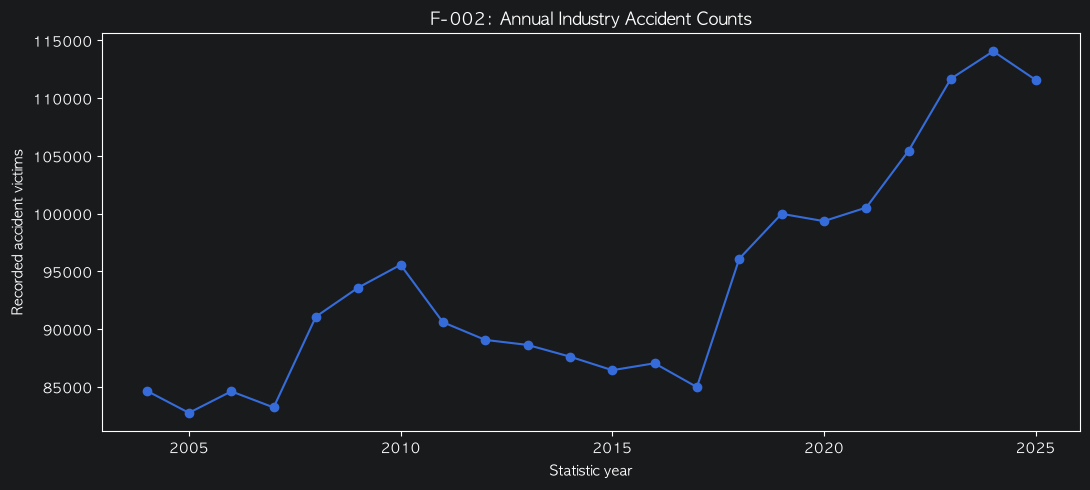

In [20]:
import matplotlib.pyplot as plt
from IPython.display import display

yearly = (
    industry_clean.groupby("statistic_year", as_index=False)
    .agg(
        accident_count=("accident_count", "sum"),
        industry_groups=("industry_middle", "nunique")
    )
    .sort_values("statistic_year")
)

display(yearly)

ax = yearly.plot.line(
    x="statistic_year",
    y="accident_count",
    marker="o",
    figsize=(11, 5),
    legend=False,
    title="F-002: Annual Industry Accident Counts"
)

ax.set_xlabel("Statistic year")
ax.set_ylabel("Recorded accident victims")
plt.tight_layout()
plt.show()

## Notebook Cell 20 — 업종명 정규화 및 이중 집계 제거

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

source = datasets["accident_industry_stat"].copy()

# 1. 업종명 표기 정규화
def normalize_industry(value):
    if pd.isna(value):
        return None

    name = str(value).strip()
    name = "".join(name.split())

    aliases = {
        "운수·창고및통신업": "운수·창고·통신업",
        "운수·창고·통신업": "운수·창고·통신업",
    }

    return aliases.get(name, name)


source["industry_major_clean"] = (
    source["industry_major"].apply(normalize_industry)
)

source["industry_middle_clean"] = (
    source["industry_middle"].apply(normalize_industry)
)

source["metric_value"] = pd.to_numeric(
    source["metric_value"],
    errors="coerce"
)

# 2. 정규화된 집계 키
keys = [
    "statistic_year",
    "industry_major_clean",
    "industry_middle_clean",
    "accident_category",
    "metric_name",
]

# 3. 집계 키별 측정값 검증
audit = (
    source.groupby(keys, dropna=False)
    .agg(
        records=("id", "size"),
        distinct_values=("metric_value", "nunique"),
        accident_count=("metric_value", "first"),
        endpoints=("source_endpoint", "nunique"),
    )
    .reset_index()
)

# 4. 수치가 유일한 그룹만 유지
industry_clean_v2 = audit[
    audit["distinct_values"].eq(1)
    & audit["accident_count"].notna()
    & audit["accident_count"].ge(0)
].copy()

industry_conflicts_v2 = audit[
    audit["distinct_values"].ne(1)
].copy()

print("원본 행:", len(source))
print("정규화 후 분석 그룹:", len(industry_clean_v2))
print("측정값 충돌·누락 그룹:", len(industry_conflicts_v2))

display(industry_clean_v2.head(10))
display(industry_conflicts_v2.head(10))

assert not industry_clean_v2.duplicated(subset=keys).any()

원본 행: 2880
정규화 후 분석 그룹: 657
측정값 충돌·누락 그룹: 12


,statistic_year,industry_major_clean,industry_middle_clean,accident_category,metric_name,records,distinct_values,accident_count,endpoints
0,2004,건설업,건설업,사고재해,사고재해자수,5,1,18856.0,5
3,2004,금융및보험업,금융및보험업,사고재해,사고재해자수,5,1,468.0,5
4,2004,기타의사업,국가및지방자치단체의사업,사고재해,사고재해자수,5,1,0.0,5
5,2004,기타의사업,기타의각종사업,사고재해,사고재해자수,5,1,1930.0,5
6,2004,기타의사업,도소매·음식·숙박업,사고재해,사고재해자수,5,1,8346.0,5
7,2004,기타의사업,부동산업및임대업,사고재해,사고재해자수,5,1,128.0,5
8,2004,기타의사업,시설관리및사업지원서비스업,사고재해,사고재해자수,5,1,7143.0,5
9,2004,기타의사업,전문·보건·교육·여가관련서비스업,사고재해,사고재해자수,5,1,3277.0,5
10,2004,기타의사업,주한미군,사고재해,사고재해자수,5,1,0.0,5
11,2004,기타의사업,해외파견자,사고재해,사고재해자수,5,1,1.0,5


,statistic_year,industry_major_clean,industry_middle_clean,accident_category,metric_name,records,distinct_values,accident_count,endpoints
1,2004,광업,석탄광업및채석업,사고재해,사고재해자수,5,2,164.0,5
2,2004,광업,석회석·금속·비금속광업및기타광업,사고재해,사고재해자수,5,2,255.0,5
33,2005,광업,석탄광업및채석업,사고재해,사고재해자수,5,2,110.0,5
34,2005,광업,석회석·금속·비금속광업및기타광업,사고재해,사고재해자수,5,2,227.0,5
65,2006,광업,석탄광업및채석업,사고재해,사고재해자수,5,2,102.0,5
66,2006,광업,석회석·금속·비금속광업및기타광업,사고재해,사고재해자수,5,2,206.0,5
97,2007,광업,석탄광업및채석업,사고재해,사고재해자수,5,2,115.0,5
98,2007,광업,석회석·금속·비금속광업및기타광업,사고재해,사고재해자수,5,2,178.0,5
161,2009,광업,석탄광업및채석업,사고재해,사고재해자수,5,2,88.0,5
162,2009,광업,석회석·금속·비금속광업및기타광업,사고재해,사고재해자수,5,2,160.0,5


## Notebook Cell 21 — 정리 전후 추세 비교

,Before,After,difference
statistic_year,,,
2004,84677.0,80021.0,4656.0
2005,82758.0,78340.0,4418.0
2006,84621.0,80122.0,4499.0
2007,83227.0,79061.0,4166.0
2008,91091.0,86768.0,4323.0
2009,93605.0,89565.0,4040.0
2010,95577.0,91510.0,4067.0
2011,90606.0,86649.0,3957.0
2012,89075.0,85164.0,3911.0


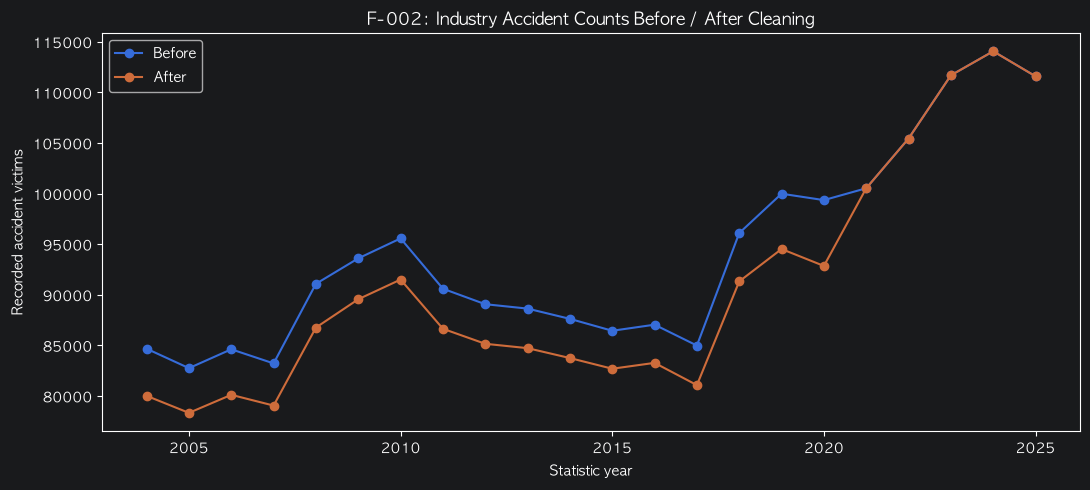

정리 전후 집계 차이가 있는 연도: 17


In [22]:
# 기존 Cell 19 결과
before = (
    industry_clean.groupby("statistic_year")["accident_count"]
    .sum()
    .rename("Before")
)

# 수정된 Cell 20 결과
after = (
    industry_clean_v2.groupby("statistic_year")["accident_count"]
    .sum()
    .rename("After")
)

comparison = pd.concat([before, after], axis=1)

comparison["difference"] = (
    comparison["Before"] - comparison["After"]
)

display(comparison)

ax = comparison[["Before", "After"]].plot(
    figsize=(11, 5),
    marker="o",
    title="F-002: Industry Accident Counts Before / After Cleaning",
)

ax.set_xlabel("Statistic year")
ax.set_ylabel("Recorded accident victims")
plt.tight_layout()
plt.show()

print(
    "정리 전후 집계 차이가 있는 연도:",
    int(comparison["difference"].ne(0).sum())
)

## Cell 22 — 업종별 통계 정제 최종 확정

In [23]:

import pandas as pd
from IPython.display import display

source = datasets["accident_industry_stat"].copy()

# 기존 Cell 20의 정규화 함수 사용
source["industry_major_clean"] = (
    source["industry_major"].apply(normalize_industry)
)
source["industry_middle_clean"] = (
    source["industry_middle"].apply(normalize_industry)
)

source["metric_value"] = pd.to_numeric(
    source["metric_value"], errors="coerce"
)

keys = [
    "statistic_year",
    "industry_major_clean",
    "industry_middle_clean",
    "accident_category",
    "metric_name",
]

# 같은 연도·업종·사고유형에 대한 수치 비교
audit_final = (
    source.groupby(keys, dropna=False)
    .agg(
        source_rows=("id", "size"),
        value_count=("metric_value", "nunique"),
        missing_values=("metric_value", lambda s: s.isna().sum()),
        accident_count=("metric_value", "first"),
        source_count=("source_endpoint", "nunique"),
    )
    .reset_index()
)

# 모든 수치가 존재하고 하나의 값으로 일치하는 경우만 통과
audit_final["quality_status"] = "CONFLICT"

valid = (
    audit_final["value_count"].eq(1)
    & audit_final["missing_values"].eq(0)
    & audit_final["accident_count"].ge(0)
)

audit_final.loc[valid, "quality_status"] = "PASS"

# 분석용 데이터와 검토용 데이터를 분리
industry_final = audit_final[
    audit_final["quality_status"] == "PASS"
].copy()

industry_review = audit_final[
    audit_final["quality_status"] != "PASS"
].copy()

print("=== F-002 정제 결과 ===")
print("원본 행:", len(source))
print("유효 집계 그룹:", len(industry_final))
print("검토 필요 그룹:", len(industry_review))

display(
    audit_final["quality_status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="groups")
)

display(industry_review.head(20))

# 결과 검사
assert not industry_final.duplicated(subset=keys).any()
assert industry_final["accident_count"].notna().all()
assert industry_final["accident_count"].ge(0).all()


=== F-002 정제 결과 ===
원본 행: 2880
유효 집계 그룹: 657
검토 필요 그룹: 12


,status,groups
0,PASS,657
1,CONFLICT,12


,statistic_year,industry_major_clean,industry_middle_clean,accident_category,metric_name,source_rows,value_count,missing_values,accident_count,source_count,quality_status
1,2004,광업,석탄광업및채석업,사고재해,사고재해자수,5,2,0,164.0,5,CONFLICT
2,2004,광업,석회석·금속·비금속광업및기타광업,사고재해,사고재해자수,5,2,0,255.0,5,CONFLICT
33,2005,광업,석탄광업및채석업,사고재해,사고재해자수,5,2,0,110.0,5,CONFLICT
34,2005,광업,석회석·금속·비금속광업및기타광업,사고재해,사고재해자수,5,2,0,227.0,5,CONFLICT
65,2006,광업,석탄광업및채석업,사고재해,사고재해자수,5,2,0,102.0,5,CONFLICT
66,2006,광업,석회석·금속·비금속광업및기타광업,사고재해,사고재해자수,5,2,0,206.0,5,CONFLICT
97,2007,광업,석탄광업및채석업,사고재해,사고재해자수,5,2,0,115.0,5,CONFLICT
98,2007,광업,석회석·금속·비금속광업및기타광업,사고재해,사고재해자수,5,2,0,178.0,5,CONFLICT
161,2009,광업,석탄광업및채석업,사고재해,사고재해자수,5,2,0,88.0,5,CONFLICT
162,2009,광업,석회석·금속·비금속광업및기타광업,사고재해,사고재해자수,5,2,0,160.0,5,CONFLICT


## Cell 23 — 최종 분석 데이터 저장 및 검증

In [24]:
from pathlib import Path
import pandas as pd
from IPython.display import display

# 기존 Notebook에서 탐색한 AI_ROOT 사용
FEATURE_DIR = (
    AI_ROOT / "src" / "features" / "f002_risk"
)

DATA_DIR = FEATURE_DIR / "artifacts" / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# 필수 데이터 검사
assert len(industry_final) > 0
assert not industry_final.duplicated(subset=keys).any()

# 정제 결과 저장
clean_path = DATA_DIR / "industry_accident_clean.csv"
review_path = DATA_DIR / "industry_accident_review.csv"

industry_final.to_csv(
    clean_path,
    index=False,
    encoding="utf-8-sig",
)

industry_review.to_csv(
    review_path,
    index=False,
    encoding="utf-8-sig",
)

# 저장 후 재검증
loaded = pd.read_csv(clean_path)

assert len(loaded) == len(industry_final)
assert loaded["accident_count"].notna().all()

print("=== F-002 데이터 저장 완료 ===")
print("정제 데이터:", clean_path)
print("검토 데이터:", review_path)

print("정제 데이터 건수:", len(loaded))
print("검토 그룹 건수:", len(industry_review))

display(loaded.head(10))

=== F-002 데이터 저장 완료 ===
정제 데이터: /Users/jeong-yelim/IF_portfolio/ai/src/features/f002_risk/artifacts/data/industry_accident_clean.csv
검토 데이터: /Users/jeong-yelim/IF_portfolio/ai/src/features/f002_risk/artifacts/data/industry_accident_review.csv
정제 데이터 건수: 657
검토 그룹 건수: 12


,statistic_year,industry_major_clean,industry_middle_clean,accident_category,metric_name,source_rows,value_count,missing_values,accident_count,source_count,quality_status
0,2004,건설업,건설업,사고재해,사고재해자수,5,1,0,18856.0,5,PASS
1,2004,금융및보험업,금융및보험업,사고재해,사고재해자수,5,1,0,468.0,5,PASS
2,2004,기타의사업,국가및지방자치단체의사업,사고재해,사고재해자수,5,1,0,0.0,5,PASS
3,2004,기타의사업,기타의각종사업,사고재해,사고재해자수,5,1,0,1930.0,5,PASS
4,2004,기타의사업,도소매·음식·숙박업,사고재해,사고재해자수,5,1,0,8346.0,5,PASS
5,2004,기타의사업,부동산업및임대업,사고재해,사고재해자수,5,1,0,128.0,5,PASS
6,2004,기타의사업,시설관리및사업지원서비스업,사고재해,사고재해자수,5,1,0,7143.0,5,PASS
7,2004,기타의사업,전문·보건·교육·여가관련서비스업,사고재해,사고재해자수,5,1,0,3277.0,5,PASS
8,2004,기타의사업,주한미군,사고재해,사고재해자수,5,1,0,0.0,5,PASS
9,2004,기타의사업,해외파견자,사고재해,사고재해자수,5,1,0,1.0,5,PASS


## Notebook Cell 24 — 기존 직무 5개 조회

In [29]:
from pathlib import Path
import pandas as pd
from IPython.display import display

# 기존 Notebook에서 설정한 AI_ROOT 사용
root = Path(AI_ROOT)

# F-001 산출물 폴더
feature_dir = root / "src/features/f001_job_task"

search_roots = [
    feature_dir / "artifacts",
    root / "artifacts/f001",  # 이전 구조도 확인
]

# 직무 데이터로 사용할 가능성이 있는 CSV 검색
keywords = [
    "job_context",
    "job_label",
    "task_label",
    "training",
]

found_files = []

for folder in search_roots:
    if not folder.exists():
        continue

    for path in folder.rglob("*.csv"):
        if any(word in path.name.lower() for word in keywords):
            found_files.append(path)

results = []

for path in sorted(set(found_files)):
    try:
        df = pd.read_csv(path, low_memory=False)

        results.append({
            "file": path.name,
            "rows": len(df),
            "columns": len(df.columns),
            "column_names": ", ".join(df.columns.tolist()),
            "path": str(path),
        })

    except Exception as exc:
        results.append({
            "file": path.name,
            "rows": None,
            "columns": None,
            "column_names": f"ERROR: {exc}",
            "path": str(path),
        })

file_inventory = pd.DataFrame(results)

print("=== F-001 데이터 파일 목록 ===")

if file_inventory.empty:
    print("F-001 CSV 파일을 찾지 못했습니다.")
else:
    display(file_inventory)

    print("\n=== 직무 컨텍스트 데이터 후보 ===")

    display(
        file_inventory[
            file_inventory["file"].str.contains(
                "job_context|job_label",
                case=False,
                regex=True,
            )
        ]
    )

=== F-001 데이터 파일 목록 ===


,file,rows,columns,column_names,path
0,job_context_clean.csv,5779,8,"dataset_code, source_record_key, region_code, region_name, organization_code, organization_name, organization_type, source_endpoint",/Users/jeong-yelim/IF_portfolio/ai/src/features/f001_job_task/artifacts/data/job_context_clean.csv
1,job_label_candidates.csv,20000,13,"source_dataset, raw_id, job_id, title, organization, source_job_code, source_job_class, candidate_category, matched_categories, matched_keywords, ...",/Users/jeong-yelim/IF_portfolio/ai/src/features/f001_job_task/artifacts/data/job_label_candidates.csv
2,job_label_review.csv,337,7,"job_id, title, candidate_category, matched_keywords, review_status, approved_label, review_note",/Users/jeong-yelim/IF_portfolio/ai/src/features/f001_job_task/artifacts/data/job_label_review.csv
3,task_label_candidates.csv,20000,7,"job_id, title, candidate_labels, evidence, label_count, label_source, review_status",/Users/jeong-yelim/IF_portfolio/ai/src/features/f001_job_task/artifacts/data/task_label_candidates.csv
4,task_label_review.csv,20000,9,"job_id, title, candidate_labels, evidence, label_count, label_source, review_status, approved_labels, review_note",/Users/jeong-yelim/IF_portfolio/ai/src/features/f001_job_task/artifacts/data/task_label_review.csv
5,task_label_summary.csv,10,2,"label, count",/Users/jeong-yelim/IF_portfolio/ai/src/features/f001_job_task/artifacts/data/task_label_summary.csv



=== 직무 컨텍스트 데이터 후보 ===


,file,rows,columns,column_names,path
0,job_context_clean.csv,5779,8,"dataset_code, source_record_key, region_code, region_name, organization_code, organization_name, organization_type, source_endpoint",/Users/jeong-yelim/IF_portfolio/ai/src/features/f001_job_task/artifacts/data/job_context_clean.csv
1,job_label_candidates.csv,20000,13,"source_dataset, raw_id, job_id, title, organization, source_job_code, source_job_class, candidate_category, matched_categories, matched_keywords, ...",/Users/jeong-yelim/IF_portfolio/ai/src/features/f001_job_task/artifacts/data/job_label_candidates.csv
2,job_label_review.csv,337,7,"job_id, title, candidate_category, matched_keywords, review_status, approved_label, review_note",/Users/jeong-yelim/IF_portfolio/ai/src/features/f001_job_task/artifacts/data/job_label_review.csv


## Cell 24 — 실제 F-001 직무 20,000건 불러오기

In [30]:
from pathlib import Path
import pandas as pd
from IPython.display import display

F001_DATA = (
    AI_ROOT
    / "src/features/f001_job_task/artifacts/data"
)

F002_DATA = (
    AI_ROOT
    / "src/features/f002_risk/artifacts/data"
)

# F-001 직무명·직무군 후보
jobs = pd.read_csv(
    F001_DATA / "job_label_candidates.csv",
    low_memory=False
)

# F-001 검수 데이터
review = pd.read_csv(
    F001_DATA / "job_label_review.csv",
    low_memory=False
)

# F-001 작업 특성 후보
tasks = pd.read_csv(
    F001_DATA / "task_label_candidates.csv",
    low_memory=False
)

# F-002 정제 산업재해 통계
industry_data = pd.read_csv(
    F002_DATA / "industry_accident_clean.csv"
)

print("=== 데이터 연결 준비 ===")
print("F-001 직무 후보:", len(jobs))
print("F-001 검수 데이터:", len(review))
print("F-001 작업 특성 후보:", len(tasks))
print("F-002 산업재해 집계:", len(industry_data))

print("\n=== F-001 직무 데이터 ===")
display(jobs.head(10))

print("\n=== 직무군 후보 분포 ===")
display(jobs["candidate_category"].value_counts(dropna=False))

print("\n=== F-001 검수 상태 ===")
display(review["review_status"].value_counts(dropna=False))

=== 데이터 연결 준비 ===
F-001 직무 후보: 20000
F-001 검수 데이터: 337
F-001 작업 특성 후보: 20000
F-002 산업재해 집계: 657

=== F-001 직무 데이터 ===


,source_dataset,raw_id,job_id,title,organization,source_job_code,source_job_class,candidate_category,matched_categories,matched_keywords,label_source,review_status,approved_label
0,PUB-012,15504,KJ21062610080016,[평화동 건설현장 격일제] 경비원 모집,국도안전관리(주),NaN,NaN,SECURITY,"[""SECURITY""]","[""경비"", ""경비원""]",TITLE_KEYWORD_RULE_V2,PENDING,NaN
1,PUB-012,15505,K180522610080006,미화원 모집 (현대프라자-능곡),삼성종합관리(주),NaN,NaN,CLEANING,"[""CLEANING""]","[""미화""]",TITLE_KEYWORD_RULE_V2,PENDING,NaN
2,PUB-012,15506,KJRV002610080001,[청송보현요양원] 간호조무사 구인,청송보현요양원,NaN,NaN,UNKNOWN,[],[],TITLE_KEYWORD_RULE_V2,UNCLASSIFIED,NaN
3,PUB-012,15507,KJ21162610080001,제2026-5호 강릉종합사회복지관 직원채용 공고 (강원공동모금회 사업 담당자),강릉종합사회복지관,A01006,농림어업,UNKNOWN,[],[],TITLE_KEYWORD_RULE_V2,UNCLASSIFIED,NaN
4,PUB-012,15508,K120412610080001,"[주5일] 대구 현풍휴게소 상/하행 조리원, 판매원 채용",주식회사 삼구에프에스,NaN,NaN,MULTI_MATCH,"[""KITCHEN"", ""SALES""]","[""조리"", ""조리원"", ""판매"", ""판매원""]",TITLE_KEYWORD_RULE_V2,AMBIGUOUS,NaN
5,PUB-012,15509,K161232610080005,아파트 관리원 모집,(주)서영주택관리,NaN,NaN,UNKNOWN,[],[],TITLE_KEYWORD_RULE_V2,UNCLASSIFIED,NaN
6,PUB-012,15510,K161132610080007,사단법인 라엘 자립생활지원실(IL) 사회복지사 채용 공고,사단법인 라엘,A01006,농림어업,CARE,"[""CARE""]","[""사회복지사""]",TITLE_KEYWORD_RULE_V2,PENDING,NaN
7,PUB-012,15511,K180032610080027,화성함백산추모공원 청소용역 대체근로자 모집(계약직),더 아름다운 세상,NaN,NaN,CLEANING,"[""CLEANING""]","[""청소""]",TITLE_KEYWORD_RULE_V2,PENDING,NaN
8,PUB-012,15512,KJAF002610080006,[2026년 관악구 취업박람회 ◆ 10월 13일(화) 13:30~17:00 관악구청8층 대강당 ◆] (주)서초택시 운전기사님 구인,(주)서초택시,NaN,NaN,DRIVING,"[""DRIVING""]","[""운전기사""]",TITLE_KEYWORD_RULE_V2,PENDING,NaN
9,PUB-012,15513,K120122610080018,[삼구INC] 삼성스토어 동탄역점 미화원 모집 (평일),（주）삼구아이앤씨,NaN,NaN,CLEANING,"[""CLEANING""]","[""미화""]",TITLE_KEYWORD_RULE_V2,PENDING,NaN



=== 직무군 후보 분포 ===


candidate_category
CLEANING         6357
UNKNOWN          5463
SECURITY         2820
CARE             1277
OFFICE            963
MANUFACTURING     905
FACILITY          615
DRIVING           547
KITCHEN           539
MULTI_MATCH       365
SALES             142
AGRICULTURE         7
Name: count, dtype: int64


=== F-001 검수 상태 ===


review_status
PENDING         277
AMBIGUOUS        30
UNCLASSIFIED     30
Name: count, dtype: int64

## Cell 25 — 직무와 산업분류 연결 가능성 확인

In [31]:
# F-001의 직무군 목록
job_categories = (
    jobs["candidate_category"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

# F-002의 산업 대분류 목록
industry_categories = (
    industry_data["industry_major_clean"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

print("=== F-001 직무군 후보 ===")
display(job_categories.to_frame("job_category"))

print("=== F-002 산업 대분류 ===")
display(industry_categories.to_frame("industry_major"))

# 아직 매핑이 검증되지 않았으므로
# 모든 직무군을 검토 대상으로 설정
mapping_review = pd.DataFrame({
    "job_category": job_categories,
    "industry_major": None,
    "mapping_status": "REVIEW_REQUIRED",
    "mapping_evidence": None,
})

display(mapping_review)

=== F-001 직무군 후보 ===


,job_category
0,AGRICULTURE
1,CARE
2,CLEANING
3,DRIVING
4,FACILITY
5,KITCHEN
6,MANUFACTURING
7,MULTI_MATCH
8,OFFICE
9,SALES


=== F-002 산업 대분류 ===


,industry_major
0,건설업
1,광업
2,금융및보험업
3,기타의사업
4,농업
5,어업
6,운수·창고·통신업
7,임업
8,전기·가스·증기·수도사업
9,전기·가스·증기및수도사업


,job_category,industry_major,mapping_status,mapping_evidence
0,AGRICULTURE,None,REVIEW_REQUIRED,None
1,CARE,None,REVIEW_REQUIRED,None
2,CLEANING,None,REVIEW_REQUIRED,None
3,DRIVING,None,REVIEW_REQUIRED,None
4,FACILITY,None,REVIEW_REQUIRED,None
5,KITCHEN,None,REVIEW_REQUIRED,None
6,MANUFACTURING,None,REVIEW_REQUIRED,None
7,MULTI_MATCH,None,REVIEW_REQUIRED,None
8,OFFICE,None,REVIEW_REQUIRED,None
9,SALES,None,REVIEW_REQUIRED,None


## Cell 26 — 직무군별 산업분류 후보 만들기

In [32]:
import pandas as pd
from IPython.display import display

# 실제 확인된 산업 대분류를 기준으로 후보 지정
industry_suggestions = {
    "AGRICULTURE": ["농업"],
    "CARE": ["기타의사업"],
    "CLEANING": ["기타의사업"],
    "DRIVING": ["운수·창고·통신업"],
    "FACILITY": ["기타의사업"],
    "KITCHEN": ["기타의사업"],
    "MANUFACTURING": ["제조업"],
    "MULTI_MATCH": [],
    "OFFICE": [],
    "SALES": ["기타의사업"],
    "SECURITY": ["기타의사업"],
    "UNKNOWN": [],
}

# 실제 산업 목록에 존재하는 후보만 허용
available_industries = set(
    industry_data["industry_major_clean"].dropna()
)

rows = []

for category in sorted(jobs["candidate_category"].dropna().unique()):
    suggestions = industry_suggestions.get(category, [])
    suggestions = [
        name for name in suggestions
        if name in available_industries
    ]

    rows.append({
        "job_category": category,
        "job_count": int(
            jobs["candidate_category"].eq(category).sum()
        ),
        "industry_candidates": ", ".join(suggestions),
        "mapping_status": "REVIEW_REQUIRED",
        "mapping_evidence": (
            "직무군 기반 탐색 후보. 실제 사업장 업종 미확인"
            if suggestions else
            "직무군만으로 산업분류 결정 불가"
        ),
    })

mapping_candidates = pd.DataFrame(rows)

display(mapping_candidates)

assert mapping_candidates["job_count"].sum() == len(jobs)
assert mapping_candidates["job_category"].is_unique

,job_category,job_count,industry_candidates,mapping_status,mapping_evidence
0,AGRICULTURE,7,농업,REVIEW_REQUIRED,직무군 기반 탐색 후보. 실제 사업장 업종 미확인
1,CARE,1277,기타의사업,REVIEW_REQUIRED,직무군 기반 탐색 후보. 실제 사업장 업종 미확인
2,CLEANING,6357,기타의사업,REVIEW_REQUIRED,직무군 기반 탐색 후보. 실제 사업장 업종 미확인
3,DRIVING,547,운수·창고·통신업,REVIEW_REQUIRED,직무군 기반 탐색 후보. 실제 사업장 업종 미확인
4,FACILITY,615,기타의사업,REVIEW_REQUIRED,직무군 기반 탐색 후보. 실제 사업장 업종 미확인
5,KITCHEN,539,기타의사업,REVIEW_REQUIRED,직무군 기반 탐색 후보. 실제 사업장 업종 미확인
6,MANUFACTURING,905,제조업,REVIEW_REQUIRED,직무군 기반 탐색 후보. 실제 사업장 업종 미확인
7,MULTI_MATCH,365,,REVIEW_REQUIRED,직무군만으로 산업분류 결정 불가
8,OFFICE,963,,REVIEW_REQUIRED,직무군만으로 산업분류 결정 불가
9,SALES,142,기타의사업,REVIEW_REQUIRED,직무군 기반 탐색 후보. 실제 사업장 업종 미확인


## Cell 27 — F-001 직무 20,000건과 산업분류 후보 연결

In [33]:
import pandas as pd
from IPython.display import display

# F-001 직무 데이터
job_mapping = jobs[
    ["job_id", "title", "candidate_category", "organization"]
].copy()

# 직무군별 산업분류 후보 연결
job_mapping = job_mapping.merge(
    mapping_candidates[
        [
            "job_category",
            "industry_candidates",
            "mapping_status",
            "mapping_evidence",
        ]
    ],
    left_on="candidate_category",
    right_on="job_category",
    how="left",
    validate="many_to_one",
    indicator=True,
)

# 불필요한 중복 컬럼 제거
job_mapping = job_mapping.drop(columns=["job_category"])

# 매핑 검토 상태 보정
job_mapping["mapping_status"] = (
    job_mapping["mapping_status"]
    .fillna("REVIEW_REQUIRED")
)

# 산업분류 후보가 있는지 확인
job_mapping["has_industry_candidate"] = (
    job_mapping["industry_candidates"]
    .fillna("")
    .str.strip()
    .ne("")
)

print("=== F-001 → F-002 매핑 결과 ===")
print("원본 직무:", len(jobs))
print("매핑 후 직무:", len(job_mapping))
print(
    "산업분류 후보가 있는 직무:",
    int(job_mapping["has_industry_candidate"].sum())
)
print(
    "산업분류 후보가 없는 직무:",
    int((~job_mapping["has_industry_candidate"]).sum())
)

print("\n=== JOIN 검증 ===")
display(job_mapping["_merge"].value_counts())

print("\n=== 직무군별 매핑 현황 ===")
mapping_summary = (
    job_mapping.groupby("candidate_category", dropna=False)
    .agg(
        job_count=("title", "size"),
        candidate_count=("has_industry_candidate", "sum"),
    )
    .reset_index()
)

display(mapping_summary)

# 필수 검증
assert len(job_mapping) == len(jobs)
assert job_mapping["_merge"].eq("both").all()
assert job_mapping["mapping_status"].eq("REVIEW_REQUIRED").all()

=== F-001 → F-002 매핑 결과 ===
원본 직무: 20000
매핑 후 직무: 20000
산업분류 후보가 있는 직무: 13209
산업분류 후보가 없는 직무: 6791

=== JOIN 검증 ===


_merge
both          20000
left_only         0
right_only        0
Name: count, dtype: int64


=== 직무군별 매핑 현황 ===


,candidate_category,job_count,candidate_count
0,AGRICULTURE,7,7
1,CARE,1277,1277
2,CLEANING,6357,6357
3,DRIVING,547,547
4,FACILITY,615,615
5,KITCHEN,539,539
6,MANUFACTURING,905,905
7,MULTI_MATCH,365,0
8,OFFICE,963,0
9,SALES,142,142


## Cell 28 — 매핑 후보 분포 시각화

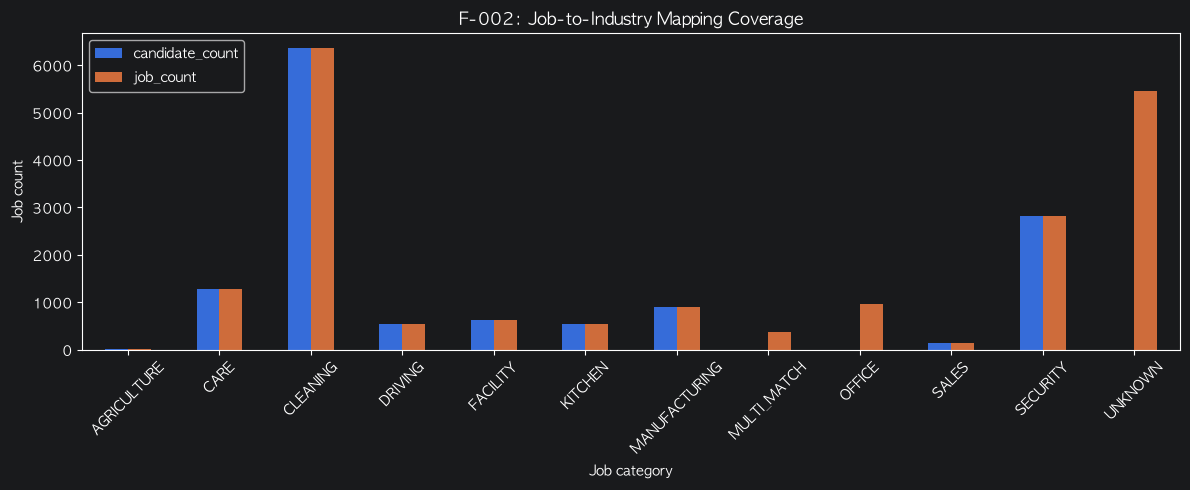

=== 산업분류 후보가 없는 직무군 ===


,candidate_category,job_count,candidate_count
7,MULTI_MATCH,365,0
8,OFFICE,963,0
11,UNKNOWN,5463,0


In [34]:
import matplotlib.pyplot as plt

plot_data = mapping_summary.set_index(
    "candidate_category"
)[["candidate_count", "job_count"]]

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 5),
    title="F-002: Job-to-Industry Mapping Coverage",
)

ax.set_ylabel("Job count")
ax.set_xlabel("Job category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("=== 산업분류 후보가 없는 직무군 ===")

display(
    mapping_summary[
        mapping_summary["candidate_count"] == 0
    ]
)

## Cell 29 — 산업별 통계 근거 테이블 생성

In [35]:
import pandas as pd
from IPython.display import display

industry = industry_data.copy()

# 집계 단위 검증
keys = [
    "statistic_year",
    "industry_major_clean",
    "industry_middle_clean",
    "accident_category",
    "metric_name",
]

assert not industry.duplicated(subset=keys).any()

# 충돌 그룹을 제외한 통계만 사용
industry = industry[
    industry["quality_status"].eq("PASS")
].copy()

# 연도·산업 대분류별 집계
industry_yearly = (
    industry.groupby(
        ["statistic_year", "industry_major_clean"],
        as_index=False
    )
    .agg(
        accident_count=("accident_count", "sum"),
        included_groups=("industry_middle_clean", "nunique"),
        source_groups=("source_rows", "sum")
    )
)

# 산업별 연도 커버리지
industry_coverage = (
    industry_yearly.groupby(
        "industry_major_clean", as_index=False
    )
    .agg(
        first_year=("statistic_year", "min"),
        last_year=("statistic_year", "max"),
        years_observed=("statistic_year", "nunique"),
    )
)

print("=== 산업별 통계 커버리지 ===")
display(industry_coverage)

print("=== 산업·연도별 재해 건수 ===")
display(industry_yearly.tail(20))

=== 산업별 통계 커버리지 ===


,industry_major_clean,first_year,last_year,years_observed
0,건설업,2004,2025,22
1,광업,2008,2020,11
2,금융및보험업,2004,2025,22
3,기타의사업,2004,2025,22
4,농업,2004,2020,17
5,어업,2004,2020,17
6,운수·창고·통신업,2004,2025,22
7,임업,2004,2020,17
8,전기·가스·증기·수도사업,2004,2025,22
9,전기·가스·증기및수도사업,2004,2020,17


=== 산업·연도별 재해 건수 ===


,statistic_year,industry_major_clean,accident_count,included_groups,source_groups
191,2022,전기·가스·증기·수도사업,105.0,1,3
192,2022,제조업,23764.0,11,40
193,2023,건설업,26829.0,1,3
194,2023,금융및보험업,522.0,1,3
195,2023,기타의사업,45792.0,8,24
196,2023,운수·창고·통신업,14039.0,3,9
197,2023,전기·가스·증기·수도사업,104.0,1,3
198,2023,제조업,24403.0,11,33
199,2024,건설업,25152.0,1,2
200,2024,금융및보험업,539.0,1,2


## Cell 30 — F-001 직무에 통계 근거 연결

In [36]:
# 산업별 가장 최근 관측연도의 통계
latest_industry = (
    industry_yearly.sort_values("statistic_year")
    .drop_duplicates(
        "industry_major_clean",
        keep="last"
    )
    .rename(columns={
        "statistic_year": "evidence_year",
        "accident_count": "industry_accident_count",
    })
)

# 산업 후보가 하나만 있는 직무를 연결 대상으로 사용
job_evidence = job_mapping.copy()

job_evidence["industry_candidate"] = (
    job_evidence["industry_candidates"]
    .fillna("")
    .str.strip()
)

# 후보가 여러 개라면 자동 연결하지 않음
job_evidence.loc[
    job_evidence["industry_candidate"].str.contains(","),
    "industry_candidate"
] = ""

job_evidence = job_evidence.merge(
    latest_industry[
        [
            "industry_major_clean",
            "evidence_year",
            "industry_accident_count",
            "included_groups",
        ]
    ],
    left_on="industry_candidate",
    right_on="industry_major_clean",
    how="left",
    validate="many_to_one",
)

# 산업 후보가 있어도 공식 업종 검증은 아직 안 됨
job_evidence["evidence_status"] = "NOT_MAPPED"

has_candidate = job_evidence["industry_candidate"].ne("")
has_statistics = job_evidence["industry_accident_count"].notna()

job_evidence.loc[
    has_candidate & has_statistics,
    "evidence_status"
] = "PROVISIONAL_EVIDENCE"

job_evidence.loc[
    has_candidate & ~has_statistics,
    "evidence_status"
] = "STATISTICS_NOT_FOUND"

# 중요: 개인 사고 확률이나 위험도 점수가 아님
job_evidence["risk_score"] = None

print("=== F-002 통계 근거 연결 결과 ===")
display(job_evidence["evidence_status"].value_counts())

print("=== 샘플 ===")
display(
    job_evidence[
        [
            "job_id",
            "title",
            "candidate_category",
            "industry_candidate",
            "evidence_year",
            "industry_accident_count",
            "evidence_status",
            "risk_score",
        ]
    ].head(20)
)

# 기존 직무 20,000건 보존
assert len(job_evidence) == len(jobs)
assert job_evidence["risk_score"].isna().all()

=== F-002 통계 근거 연결 결과 ===


evidence_status
PROVISIONAL_EVIDENCE    13209
NOT_MAPPED               6791
Name: count, dtype: int64

=== 샘플 ===


,job_id,title,candidate_category,industry_candidate,evidence_year,industry_accident_count,evidence_status,risk_score
0,KJ21062610080016,[평화동 건설현장 격일제] 경비원 모집,SECURITY,기타의사업,2025.0,49471.0,PROVISIONAL_EVIDENCE,None
1,K180522610080006,미화원 모집 (현대프라자-능곡),CLEANING,기타의사업,2025.0,49471.0,PROVISIONAL_EVIDENCE,None
2,KJRV002610080001,[청송보현요양원] 간호조무사 구인,UNKNOWN,,NaN,NaN,NOT_MAPPED,None
3,KJ21162610080001,제2026-5호 강릉종합사회복지관 직원채용 공고 (강원공동모금회 사업 담당자),UNKNOWN,,NaN,NaN,NOT_MAPPED,None
4,K120412610080001,"[주5일] 대구 현풍휴게소 상/하행 조리원, 판매원 채용",MULTI_MATCH,,NaN,NaN,NOT_MAPPED,None
5,K161232610080005,아파트 관리원 모집,UNKNOWN,,NaN,NaN,NOT_MAPPED,None
6,K161132610080007,사단법인 라엘 자립생활지원실(IL) 사회복지사 채용 공고,CARE,기타의사업,2025.0,49471.0,PROVISIONAL_EVIDENCE,None
7,K180032610080027,화성함백산추모공원 청소용역 대체근로자 모집(계약직),CLEANING,기타의사업,2025.0,49471.0,PROVISIONAL_EVIDENCE,None
8,KJAF002610080006,[2026년 관악구 취업박람회 ◆ 10월 13일(화) 13:30~17:00 관악구청8층 대강당 ◆] (주)서초택시 운전기사님 구인,DRIVING,운수·창고·통신업,2025.0,16505.0,PROVISIONAL_EVIDENCE,None
9,K120122610080018,[삼구INC] 삼성스토어 동탄역점 미화원 모집 (평일),CLEANING,기타의사업,2025.0,49471.0,PROVISIONAL_EVIDENCE,None


## Cell 31 — 산업분류 충돌 및 매핑 오류 후보 검증

In [37]:
import pandas as pd
from IPython.display import display

audit_jobs = job_evidence.copy()

# 1. 직무명에서 사업장 업종을 암시하는 표현 탐색
# 단, 키워드는 업종 확정 근거가 아닌 검토 신호임
industry_signals = {
    "건설업": ["건설현장", "건설공사", "공사현장"],
    "제조업": ["제조공장", "생산공장", "제조업체"],
    "농업": ["농장", "농업법인", "영농"],
    "운수·창고·통신업": ["물류센터", "운송회사", "택배터미널"],
}

def find_signals(title):
    title = str(title or "")
    return [
        industry
        for industry, keywords in industry_signals.items()
        if any(word in title for word in keywords)
    ]

audit_jobs["industry_signals"] = (
    audit_jobs["title"].apply(find_signals)
)

# 2. 제목의 산업 신호와 기존 매핑 후보 비교
def evaluate_mapping(row):
    signals = row["industry_signals"]
    candidate = row["industry_candidate"]

    if not signals:
        return "NO_INDUSTRY_SIGNAL"

    if len(signals) > 1:
        return "MULTIPLE_SIGNALS"

    if not candidate:
        return "UNMAPPED_WITH_SIGNAL"

    if signals[0] != candidate:
        return "POSSIBLE_MISMATCH"

    return "CANDIDATE_CONSISTENT"

audit_jobs["mapping_audit"] = audit_jobs.apply(
    evaluate_mapping,
    axis=1
)

# 3. 검증 결과
print("=== 직무 산업분류 검토 결과 ===")

display(
    audit_jobs["mapping_audit"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="rows")
)

print("=== 기존 후보와 충돌 가능성이 있는 직무 ===")

display(
    audit_jobs.loc[
        audit_jobs["mapping_audit"].isin([
            "POSSIBLE_MISMATCH",
            "MULTIPLE_SIGNALS",
            "UNMAPPED_WITH_SIGNAL",
        ]),
        [
            "job_id",
            "title",
            "candidate_category",
            "industry_candidate",
            "industry_signals",
            "mapping_audit",
        ],
    ].head(30)
)

assert len(audit_jobs) == len(job_evidence)

=== 직무 산업분류 검토 결과 ===


,status,rows
0,NO_INDUSTRY_SIGNAL,19530
1,POSSIBLE_MISMATCH,296
2,UNMAPPED_WITH_SIGNAL,161
3,CANDIDATE_CONSISTENT,12
4,MULTIPLE_SIGNALS,1


=== 기존 후보와 충돌 가능성이 있는 직무 ===


,job_id,title,candidate_category,industry_candidate,industry_signals,mapping_audit
0,KJ21062610080016,[평화동 건설현장 격일제] 경비원 모집,SECURITY,기타의사업,[건설업],POSSIBLE_MISMATCH
84,KJ21062609300015,[구파발역 은평구체육센터 인근 공사현장] 경비원(주간제) 채용,SECURITY,기타의사업,[건설업],POSSIBLE_MISMATCH
139,KJ21062609220028,[부천 오정구 원종동 공사현장] 경비원(격일제) 채용,SECURITY,기타의사업,[건설업],POSSIBLE_MISMATCH
171,K180012609180039,[동탄 지마켓] 물류센터 지게차 및 일반 현장 사원 모집,UNKNOWN,,[운수·창고·통신업],UNMAPPED_WITH_SIGNAL
327,K120142609010017,[봉은사역인근 삼성동 공사현장] 경비원 모집(주간제/공사현장경비경력 필수),SECURITY,기타의사업,[건설업],POSSIBLE_MISMATCH
328,K120032609010002,건설현장 경비원 모집 (금성백조 청양현장),SECURITY,기타의사업,[건설업],POSSIBLE_MISMATCH
379,K180022608260065,용인 영덕동 건설현장 미화원 모집,CLEANING,기타의사업,[건설업],POSSIBLE_MISMATCH
392,K120032608250023,건설현장 경비원 구인(진흥 수원 우만동),SECURITY,기타의사업,[건설업],POSSIBLE_MISMATCH
425,K170052608210024,[주5일] 건설현장 사무실 미화원 모집,MULTI_MATCH,,[건설업],UNMAPPED_WITH_SIGNAL
428,K170052608210028,[주5일] 건설현장 사무실 조리원 모집,MULTI_MATCH,,[건설업],UNMAPPED_WITH_SIGNAL


## Cell 32 — 매핑 검토 결과 저장

In [38]:
from pathlib import Path

output_dir = (
    AI_ROOT / "src/features/f002_risk/artifacts/data"
)
output_dir.mkdir(parents=True, exist_ok=True)

# 기존 후보 매핑 상태는 유지하고
# 위험도 분석에 활용 가능한지 별도 기록
audit_jobs["risk_score"] = None

audit_jobs["evidence_usable"] = False

# 제목과 후보가 일치해도 검증된 산업코드는 아니므로
# 자동으로 True 처리하지 않음

save_path = output_dir / "job_industry_mapping_review.csv"

audit_jobs[
    [
        "job_id",
        "title",
        "candidate_category",
        "industry_candidate",
        "industry_signals",
        "mapping_audit",
        "evidence_status",
        "evidence_year",
        "industry_accident_count",
        "evidence_usable",
        "risk_score",
    ]
].to_csv(
    save_path,
    index=False,
    encoding="utf-8-sig",
)

saved = pd.read_csv(save_path)

assert len(saved) == len(jobs)
assert saved["risk_score"].isna().all()
assert not saved["evidence_usable"].fillna(False).any()

print("저장 완료:", save_path)
print("저장된 직무:", len(saved))

저장 완료: /Users/jeong-yelim/IF_portfolio/ai/src/features/f002_risk/artifacts/data/job_industry_mapping_review.csv
저장된 직무: 20000


## Cell 33 — 연령별 산업재해 데이터 정제

In [39]:
# Cell 33 — 연령별 산업재해 데이터 정제

import pandas as pd
from IPython.display import display

age_df = datasets["accident_age_stat"].copy()

age_df["metric_value"] = pd.to_numeric(
    age_df["metric_value"],
    errors="coerce"
)

# 같은 연도·연령·지표가 하나의 관측값인지 검증
keys = [
    "statistic_year",
    "age_group",
    "metric_name",
]

age_audit = (
    age_df.groupby(keys, dropna=False)
    .agg(
        source_rows=("id", "size"),
        unique_values=("metric_value", "nunique"),
        missing_values=("metric_value", lambda s: s.isna().sum()),
        accident_count=("metric_value", "first"),
        source_count=("source_endpoint", "nunique"),
    )
    .reset_index()
)

# 동일 그룹에서 모든 수치가 하나로 일치하는 경우만 사용
valid = (
    age_audit["unique_values"].eq(1)
    & age_audit["missing_values"].eq(0)
    & age_audit["accident_count"].ge(0)
)

age_audit["quality_status"] = "CONFLICT"
age_audit.loc[valid, "quality_status"] = "PASS"

age_clean = age_audit[
    age_audit["quality_status"] == "PASS"
].copy()

age_review = age_audit[
    age_audit["quality_status"] != "PASS"
].copy()

print("=== F-002 연령별 통계 검증 ===")
print("원본 행:", len(age_df))
print("유효 집계 그룹:", len(age_clean))
print("검토 필요 그룹:", len(age_review))

display(
    age_audit["quality_status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="groups")
)

display(age_clean.head(10))
display(age_review.head(10))

assert not age_clean.duplicated(subset=keys).any()

=== F-002 연령별 통계 검증 ===
원본 행: 1599
유효 집계 그룹: 350
검토 필요 그룹: 0


,status,groups
0,PASS,350


,statistic_year,age_group,metric_name,source_rows,unique_values,missing_values,accident_count,source_count,quality_status
0,2004,18세 ~ 24세,재해자수,6,1,0,4037.0,6,PASS
1,2004,18세 미만,재해자수,6,1,0,53.0,6,PASS
2,2004,25세 ~ 29세,재해자수,6,1,0,8188.0,6,PASS
3,2004,30세 ~ 34세,재해자수,6,1,0,10552.0,6,PASS
4,2004,35세 ~ 39세,재해자수,6,1,0,12052.0,6,PASS
5,2004,40세 ~ 44세,재해자수,6,1,0,13341.0,6,PASS
6,2004,45세 ~ 49세,재해자수,6,1,0,13287.0,6,PASS
7,2004,50세 ~ 54세,재해자수,6,1,0,10013.0,6,PASS
8,2004,55세 ~ 59세,재해자수,6,1,0,8023.0,6,PASS
9,2004,60세 ~ 64세,재해자수,4,1,0,5462.0,4,PASS


,statistic_year,age_group,metric_name,source_rows,unique_values,missing_values,accident_count,source_count,quality_status


## Cell 34 — 연령별 산업재해 건수 시각화

,statistic_year,age_group,accident_count
336,2025,18세 미만,29.0
348,2025,80세 이상,1387.0
335,2025,18세 ~ 24세,3677.0
347,2025,75세 ~ 79세,3995.0
337,2025,25세 ~ 29세,7793.0
339,2025,35세 ~ 39세,8389.0
338,2025,30세 ~ 34세,9142.0
340,2025,40세 ~ 44세,9767.0
346,2025,70세 ~ 74세,11159.0
341,2025,45세 ~ 49세,12040.0


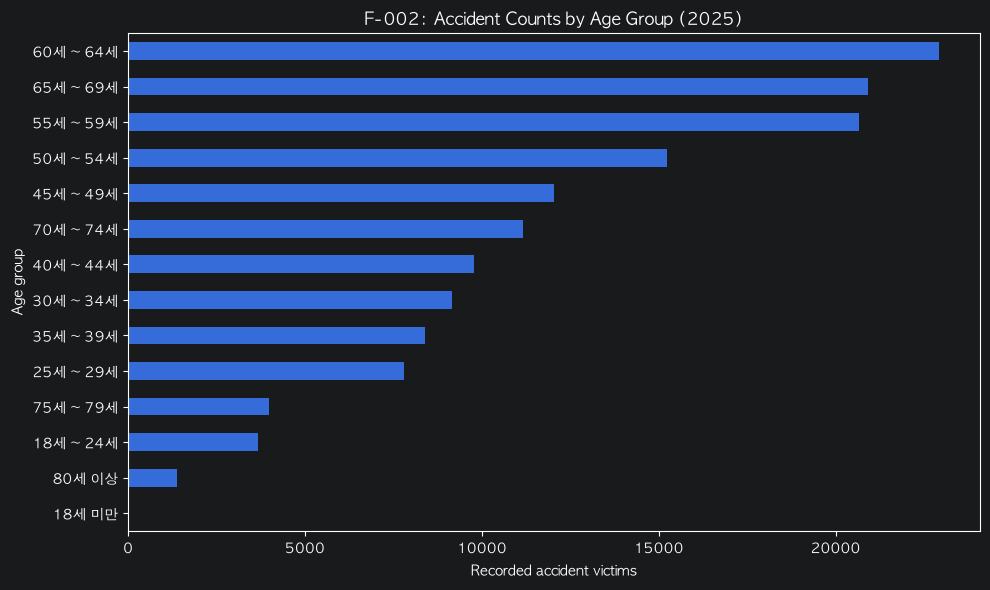

In [41]:
# Cell 34 — 연령별 추세 시각화

import matplotlib.pyplot as plt

# 연령별 비교에 사용할 관측 연도 확인
latest_year = age_clean["statistic_year"].max()

latest_age = age_clean[
    age_clean["statistic_year"] == latest_year
].copy()

# 분류불능 등 별도 항목은 그래프에서 제외
latest_age = latest_age[
    ~latest_age["age_group"].astype(str).str.contains(
        "분류불능|미상|합계|총계",
        regex=True,
    )
]

latest_age = latest_age.sort_values("accident_count")

display(
    latest_age[
        ["statistic_year", "age_group", "accident_count"]
    ]
)

ax = latest_age.plot.barh(
    x="age_group",
    y="accident_count",
    figsize=(10, 6),
    legend=False,
    title=f"F-002: Accident Counts by Age Group ({latest_year})",
)

ax.set_xlabel("Recorded accident victims")
ax.set_ylabel("Age group")

plt.tight_layout()
plt.show()

## Cell 35 — 정제 결과 저장

In [40]:
# Cell 35 — F-002 기능 폴더에 저장

AGE_DATA_DIR = (
    AI_ROOT
    / "src/features/f002_risk/artifacts/data"
)

AGE_DATA_DIR.mkdir(parents=True, exist_ok=True)

age_clean.to_csv(
    AGE_DATA_DIR / "age_accident_clean.csv",
    index=False,
    encoding="utf-8-sig",
)

age_review.to_csv(
    AGE_DATA_DIR / "age_accident_review.csv",
    index=False,
    encoding="utf-8-sig",
)

# 저장 검증
saved_age = pd.read_csv(
    AGE_DATA_DIR / "age_accident_clean.csv"
)

assert len(saved_age) == len(age_clean)
assert saved_age["quality_status"].eq("PASS").all()

print("연령별 데이터 저장 완료")
print("정제 데이터:", len(saved_age))
print("검토 데이터:", len(age_review))

연령별 데이터 저장 완료
정제 데이터: 350
검토 데이터: 0
